# Notebook 36 — Double-layer surface-form sensitivity audit

## Goal

Test whether enabling double-layer dynamics through PyBaMM's `surface form = differential` option changes the DC–AC timing, residual, microstate, or plating-margin conclusions.

Core question:

> Are the previous DC–AC conclusions sensitive to the quasi-steady interfacial charge-balance assumption used when `surface form = false`?

## Scientific context

Notebook 30–35 used the standard DFN mainline without explicitly enabling double-layer surface dynamics. Under the default surface formulation, interfacial charge balance is quasi-steady and the double-layer capacitive current is not treated as a separate dynamic state.

This notebook introduces a missing-physics sensitivity branch:

```text
surface form = false
vs
surface form = differential
```

The key hypothesis is not that double-layer dynamics must create non-geometric acceleration. The key hypothesis is:

> If AC forcing interacts with capacitive interfacial dynamics, then terminal-current first-passage, faradaic/state progression, U_NE margin, and high-frequency microstate response may differ from the quasi-steady baseline.

## Model variants

Primary comparison:

- `surface_form_false`: baseline used in prior notebooks
- `surface_form_differential`: double-layer capacitance as a dynamic state

Optional diagnostic:

- `surface_form_algebraic`: algebraic surface formulation, not a capacitance-dynamic branch

## Protocol set

Initial minimal protocol set:

- DC `0.3C`
- fixed DC–AC `0.3C + 0.38C`
- fixed DC–AC `0.3C + 0.7C`
- scheduled `sched_v2_conservative` from Day35

The schedule `sched_v2_conservative` is selected because Day35 identified it as the primary first-generation rule-based candidate.

## Required audits

This notebook must first verify:

1. whether the model option builds successfully;
2. whether double-layer capacity parameters are available;
3. whether double-layer / capacitive-current variables appear in the built model;
4. whether the same plating-margin proxy remains available:
   `Negative electrode surface potential difference [V]`.

## Interpretation boundary

- This notebook is a missing-physics sensitivity audit.
- It does not implement MPC or Bayesian optimization.
- It does not evaluate thermal or aging admissibility.
- It does not prove experimental plating or plating-free operation.
- If `Δt_resid` changes under `surface form = differential`, the change must still be separated from terminal-current geometry and from terminal-charge vs internal-state progression.

In [1]:
# Cell 1 — Imports, paths, and Day36 metadata（导入库、路径与Day36元数据）

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

warnings.filterwarnings("default")

REPO = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA_DIR = REPO / "data"
FIG_DIR = REPO / "figures"
DOCS_DIR = REPO / "docs"

for p in [DATA_DIR, FIG_DIR, DOCS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

PRIMARY_PARAMETER_SET = "Chen2020"
MODEL_TYPE = "DFN"
FREQUENCY_MODE = "set_rebased"

DC_C = 0.3
TAU_FACTOR_MAIN = 1.5
TAU_REF_SET_S = 36.316532231592305
F_MAIN_HZ = 1.0 / (2.0 * np.pi * TAU_FACTOR_MAIN * TAU_REF_SET_S)
PERIOD_MAIN_S = 1.0 / F_MAIN_HZ

PLATING_MARGIN_SAFE_BUFFER_V = 0.050

SURFACE_FORM_VARIANTS = [
    {
        "variant_id": "surface_form_false",
        "surface_form": "false",
        "interpretation": "baseline quasi-steady interfacial charge balance",
    },
    {
        "variant_id": "surface_form_differential",
        "surface_form": "differential",
        "interpretation": "dynamic double-layer capacitance branch",
    },
    {
        "variant_id": "surface_form_algebraic",
        "surface_form": "algebraic",
        "interpretation": "algebraic surface formulation diagnostic",
    },
]

DAY36_METADATA = {
    "notebook": "36_double_layer_surface_form_sensitivity.ipynb",
    "parameter_set": PRIMARY_PARAMETER_SET,
    "model_type": MODEL_TYPE,
    "frequency_mode": FREQUENCY_MODE,
    "tau_factor_main": TAU_FACTOR_MAIN,
    "tau_ref_set_s": TAU_REF_SET_S,
    "f_main_Hz": F_MAIN_HZ,
    "purpose": "double-layer surface-form sensitivity audit",
    "surface_form_variants": SURFACE_FORM_VARIANTS,
    "lineage": "Day36 tests missing interfacial double-layer dynamics after Day30-Day35.",
}

metadata_path = DATA_DIR / "day36_metadata.json"
metadata_path.write_text(json.dumps(DAY36_METADATA, indent=2), encoding="utf-8")

print("[OK] repo:", REPO)
print("[OK] pybamm version:", pybamm.__version__)
print("[OK] f_main_Hz:", F_MAIN_HZ)
print("[OK] period_main_s:", PERIOD_MAIN_S)
print("[OK] saved metadata:", metadata_path)

[OK] repo: /Users/louislu/pybamm-dcac-superimposed
[OK] pybamm version: 26.3.1
[OK] f_main_Hz: 0.002921625190367048
[OK] period_main_s: 342.27525258788194
[OK] saved metadata: /Users/louislu/pybamm-dcac-superimposed/data/day36_metadata.json


In [2]:
# Cell 2 — Double-layer parameter availability audit（双电层参数可用性审计）

parameter_values = pybamm.ParameterValues(PRIMARY_PARAMETER_SET)
param_keys = set(parameter_values.keys())

CDL_KEYS = [
    "Negative electrode double-layer capacity [F.m-2]",
    "Positive electrode double-layer capacity [F.m-2]",
]

cdl_rows = []

for key in CDL_KEYS:
    available = key in param_keys
    value_repr = ""
    value_type = ""

    if available:
        try:
            value = parameter_values[key]
            value_repr = repr(value)
            value_type = type(value).__name__
        except Exception as e:
            value_repr = f"READ_ERROR: {repr(e)}"
            value_type = "error"

    cdl_rows.append({
        "parameter_set": PRIMARY_PARAMETER_SET,
        "parameter_key": key,
        "available": available,
        "value_type": value_type,
        "value_repr": value_repr,
    })

keyword_matches = []
for key in sorted(param_keys):
    low = key.lower()
    if ("double" in low) or ("capac" in low) or ("layer" in low):
        keyword_matches.append(key)

cdl_parameter_audit_df = pd.DataFrame(cdl_rows)

out = DATA_DIR / "day36_double_layer_parameter_audit.csv"
cdl_parameter_audit_df.to_csv(out, index=False)

out2 = DATA_DIR / "day36_double_layer_parameter_keyword_inventory.csv"
pd.DataFrame({"parameter_key": keyword_matches}).to_csv(out2, index=False)

print("[OK] saved C_dl parameter audit:", out)
print("[OK] saved keyword inventory:", out2)
display(cdl_parameter_audit_df)
display(pd.DataFrame({"parameter_key": keyword_matches}).head(100))

[OK] saved C_dl parameter audit: /Users/louislu/pybamm-dcac-superimposed/data/day36_double_layer_parameter_audit.csv
[OK] saved keyword inventory: /Users/louislu/pybamm-dcac-superimposed/data/day36_double_layer_parameter_keyword_inventory.csv


,parameter_set,parameter_key,available,value_type,value_repr
0,Chen2020,Negative electrode double-layer capacity [F.m-2],True,float,0.2
1,Chen2020,Positive electrode double-layer capacity [F.m-2],True,float,0.2


,parameter_key
0,Negative current collector specific heat capac...
1,Negative electrode double-layer capacity [F.m-2]
2,Negative electrode specific heat capacity [J.k...
3,Nominal cell capacity [A.h]
4,Positive current collector specific heat capac...
5,Positive electrode double-layer capacity [F.m-2]
6,Positive electrode specific heat capacity [J.k...
7,Separator specific heat capacity [J.kg-1.K-1]


In [3]:
# Cell 3 — Build model variants and audit variables（构建模型变体并审计变量）

VARIABLE_SEARCH_TERMS = [
    "double",
    "capac",
    "surface potential difference",
    "interfacial current",
    "faradaic",
    "overpotential",
    "electrolyte concentration",
    "surface stoichiometry",
]

REQUIRED_MARGIN_KEYS = [
    "Negative electrode surface potential difference [V]",
    "Negative electrode surface potential difference at separator interface [V]",
    "X-averaged negative electrode surface potential difference [V]",
]

model_variant_rows = []
variable_rows = []

built_models = {}

for spec in SURFACE_FORM_VARIANTS:
    variant_id = spec["variant_id"]
    surface_form = spec["surface_form"]

    print(f"[BUILD] {variant_id}: surface form = {surface_form}")

    options = {
        "thermal": "isothermal",
        "surface form": surface_form,
    }

    try:
        model = pybamm.lithium_ion.DFN(options=options)
        sim = pybamm.Simulation(model, parameter_values=parameter_values)
        sim.build()

        keys = sorted(list(sim.built_model.variables.keys()))
        built_models[variant_id] = {
            "model": model,
            "sim": sim,
            "variable_keys": keys,
            "options": options,
        }

        missing_margin = [k for k in REQUIRED_MARGIN_KEYS if k not in keys]

        model_variant_rows.append({
            "variant_id": variant_id,
            "surface_form": surface_form,
            "build_status": "ok",
            "n_variables": len(keys),
            "required_margin_keys_available": len(missing_margin) == 0,
            "missing_margin_keys": "; ".join(missing_margin),
            "error": "",
        })

        for term in VARIABLE_SEARCH_TERMS:
            matches = [k for k in keys if term.lower() in k.lower()]
            for k in matches:
                variable_rows.append({
                    "variant_id": variant_id,
                    "surface_form": surface_form,
                    "search_term": term,
                    "variable_key": k,
                })

        print("[OK]", variant_id, "n_variables:", len(keys))

    except Exception as e:
        model_variant_rows.append({
            "variant_id": variant_id,
            "surface_form": surface_form,
            "build_status": "failed",
            "n_variables": np.nan,
            "required_margin_keys_available": False,
            "missing_margin_keys": "",
            "error": repr(e),
        })
        print("[FAILED]", variant_id, repr(e))

model_variant_audit_df = pd.DataFrame(model_variant_rows)
variable_audit_df = pd.DataFrame(variable_rows).drop_duplicates()

out = DATA_DIR / "day36_surface_form_model_variant_audit.csv"
model_variant_audit_df.to_csv(out, index=False)

out2 = DATA_DIR / "day36_surface_form_variable_audit.csv"
variable_audit_df.to_csv(out2, index=False)

print("[OK] saved model variant audit:", out)
print("[OK] saved variable audit:", out2)

display(model_variant_audit_df)
display(variable_audit_df.head(200))


[BUILD] surface_form_false: surface form = false
[OK] surface_form_false n_variables: 515
[BUILD] surface_form_differential: surface form = differential
[OK] surface_form_differential n_variables: 522
[BUILD] surface_form_algebraic: surface form = algebraic
[OK] surface_form_algebraic n_variables: 522
[OK] saved model variant audit: /Users/louislu/pybamm-dcac-superimposed/data/day36_surface_form_model_variant_audit.csv
[OK] saved variable audit: /Users/louislu/pybamm-dcac-superimposed/data/day36_surface_form_variable_audit.csv


,variant_id,surface_form,build_status,n_variables,required_margin_keys_available,missing_margin_keys,error
0,surface_form_false,false,ok,515,True,,
1,surface_form_differential,differential,ok,522,True,,
2,surface_form_algebraic,algebraic,ok,522,True,,


,variant_id,surface_form,search_term,variable_key
0,surface_form_false,false,capac,Discharge capacity [A.h]
1,surface_form_false,false,capac,Loss of capacity to negative SEI [A.h]
2,surface_form_false,false,capac,Loss of capacity to negative SEI on cracks [A.h]
3,surface_form_false,false,capac,Loss of capacity to negative lithium plating [...
4,surface_form_false,false,capac,Loss of capacity to positive SEI [A.h]
...,...,...,...,...
195,surface_form_differential,differential,overpotential,X-averaged negative electrode lithium plating ...
196,surface_form_differential,differential,overpotential,X-averaged negative electrode reaction overpot...
197,surface_form_differential,differential,overpotential,X-averaged positive electrode SEI film overpot...
198,surface_form_differential,differential,overpotential,X-averaged positive electrode lithium plating ...


In [4]:
# Cell 4 — Define Day36 protocol set（定义Day36协议集）

candidate_ref_files = [
    DATA_DIR / "day35_run_summary.csv",
    DATA_DIR / "day34_run_summary.csv",
    DATA_DIR / "day33b_run_summary.csv",
]

Q_REF_AH = None
for path in candidate_ref_files:
    if path.exists():
        df = pd.read_csv(path)
        dc_rows = df[df["condition"].astype(str).str.contains("DC03") & ~df["condition"].astype(str).str.contains("AC")]
        if len(dc_rows) > 0 and "Q_end_Ah" in dc_rows.columns:
            Q_REF_AH = float(dc_rows["Q_end_Ah"].iloc[0])
            print("[OK] Q_REF_AH loaded from:", path)
            break

if Q_REF_AH is None:
    Q_REF_AH = 4.4928790028035
    print("[WARN] fallback Q_REF_AH used:", Q_REF_AH)

Q_NOM_AH = float(parameter_values["Nominal cell capacity [A.h]"])
I_DC_A = DC_C * Q_NOM_AH

def qfrac_to_time_s(q_frac):
    return q_frac * Q_REF_AH * 3600.0 / I_DC_A

protocol_rows = []

base_protocol_specs = [
    {
        "protocol_id": "DC03",
        "protocol_type": "DC",
        "case_role": "dc_reference",
        "schedule_type": "constant",
        "fixed_ac_c": 0.0,
        "early_ac_c": 0.0,
        "mid_ac_c": 0.0,
        "late_ac_c": 0.0,
        "qfrac_derate": np.nan,
        "qfrac_ac_off": np.nan,
    },
    {
        "protocol_id": "fixed_AC0p38",
        "protocol_type": "DCAC",
        "case_role": "fixed_near_boundary",
        "schedule_type": "constant",
        "fixed_ac_c": 0.38,
        "early_ac_c": 0.38,
        "mid_ac_c": 0.38,
        "late_ac_c": 0.38,
        "qfrac_derate": np.nan,
        "qfrac_ac_off": np.nan,
    },
    {
        "protocol_id": "fixed_AC0p7",
        "protocol_type": "DCAC",
        "case_role": "fixed_stress",
        "schedule_type": "constant",
        "fixed_ac_c": 0.70,
        "early_ac_c": 0.70,
        "mid_ac_c": 0.70,
        "late_ac_c": 0.70,
        "qfrac_derate": np.nan,
        "qfrac_ac_off": np.nan,
    },
    {
        "protocol_id": "sched_v2_conservative",
        "protocol_type": "DCAC_SCHEDULED",
        "case_role": "day35_primary_candidate",
        "schedule_type": "qfrac_time_proxy",
        "fixed_ac_c": np.nan,
        "early_ac_c": 0.38,
        "mid_ac_c": 0.10,
        "late_ac_c": 0.00,
        "qfrac_derate": 0.70,
        "qfrac_ac_off": 0.80,
    },
]

for variant in SURFACE_FORM_VARIANTS:
    for proto in base_protocol_specs:
        protocol_rows.append({
            "variant_id": variant["variant_id"],
            "surface_form": variant["surface_form"],
            "condition": f"Chen2020_DFN_Day36_{variant['variant_id']}_{proto['protocol_id']}",
            "parameter_set": PRIMARY_PARAMETER_SET,
            "model_type": MODEL_TYPE,
            "dc_c": DC_C,
            "tau_factor_set": TAU_FACTOR_MAIN,
            "tau_ref_set_s": TAU_REF_SET_S,
            "f_Hz": F_MAIN_HZ,
            "period_s": PERIOD_MAIN_S,
            **proto,
        })

protocol_df = pd.DataFrame(protocol_rows)
protocol_df["peak_c_nominal"] = protocol_df["dc_c"] + protocol_df[["fixed_ac_c", "early_ac_c"]].max(axis=1)

out = DATA_DIR / "day36_protocol_table.csv"
protocol_df.to_csv(out, index=False)

print("[OK] saved Day36 protocol table:", out)
print("[OK] Q_REF_AH:", Q_REF_AH)
print("[OK] Q_NOM_AH:", Q_NOM_AH)
display(protocol_df)

[OK] Q_REF_AH loaded from: /Users/louislu/pybamm-dcac-superimposed/data/day35_run_summary.csv
[OK] saved Day36 protocol table: /Users/louislu/pybamm-dcac-superimposed/data/day36_protocol_table.csv
[OK] Q_REF_AH: 4.4928790028035
[OK] Q_NOM_AH: 5.0


,variant_id,surface_form,condition,parameter_set,model_type,dc_c,tau_factor_set,tau_ref_set_s,f_Hz,period_s,...,protocol_type,case_role,schedule_type,fixed_ac_c,early_ac_c,mid_ac_c,late_ac_c,qfrac_derate,qfrac_ac_off,peak_c_nominal
0,surface_form_false,false,Chen2020_DFN_Day36_surface_form_false_DC03,Chen2020,DFN,0.3,1.5,36.316532,0.002922,342.275253,...,DC,dc_reference,constant,0.00,0.00,0.00,0.00,NaN,NaN,0.30
1,surface_form_false,false,Chen2020_DFN_Day36_surface_form_false_fixed_AC...,Chen2020,DFN,0.3,1.5,36.316532,0.002922,342.275253,...,DCAC,fixed_near_boundary,constant,0.38,0.38,0.38,0.38,NaN,NaN,0.68
2,surface_form_false,false,Chen2020_DFN_Day36_surface_form_false_fixed_AC0p7,Chen2020,DFN,0.3,1.5,36.316532,0.002922,342.275253,...,DCAC,fixed_stress,constant,0.70,0.70,0.70,0.70,NaN,NaN,1.00
3,surface_form_false,false,Chen2020_DFN_Day36_surface_form_false_sched_v2...,Chen2020,DFN,0.3,1.5,36.316532,0.002922,342.275253,...,DCAC_SCHEDULED,day35_primary_candidate,qfrac_time_proxy,NaN,0.38,0.10,0.00,0.7,0.8,0.68
4,surface_form_differential,differential,Chen2020_DFN_Day36_surface_form_differential_DC03,Chen2020,DFN,0.3,1.5,36.316532,0.002922,342.275253,...,DC,dc_reference,constant,0.00,0.00,0.00,0.00,NaN,NaN,0.30
5,surface_form_differential,differential,Chen2020_DFN_Day36_surface_form_differential_f...,Chen2020,DFN,0.3,1.5,36.316532,0.002922,342.275253,...,DCAC,fixed_near_boundary,constant,0.38,0.38,0.38,0.38,NaN,NaN,0.68
6,surface_form_differential,differential,Chen2020_DFN_Day36_surface_form_differential_f...,Chen2020,DFN,0.3,1.5,36.316532,0.002922,342.275253,...,DCAC,fixed_stress,constant,0.70,0.70,0.70,0.70,NaN,NaN,1.00
7,surface_form_differential,differential,Chen2020_DFN_Day36_surface_form_differential_s...,Chen2020,DFN,0.3,1.5,36.316532,0.002922,342.275253,...,DCAC_SCHEDULED,day35_primary_candidate,qfrac_time_proxy,NaN,0.38,0.10,0.00,0.7,0.8,0.68
8,surface_form_algebraic,algebraic,Chen2020_DFN_Day36_surface_form_algebraic_DC03,Chen2020,DFN,0.3,1.5,36.316532,0.002922,342.275253,...,DC,dc_reference,constant,0.00,0.00,0.00,0.00,NaN,NaN,0.30
9,surface_form_algebraic,algebraic,Chen2020_DFN_Day36_surface_form_algebraic_fixe...,Chen2020,DFN,0.3,1.5,36.316532,0.002922,342.275253,...,DCAC,fixed_near_boundary,constant,0.38,0.38,0.38,0.38,NaN,NaN,0.68


In [5]:
# Cell 5 — Current waveform utilities and audit（电流波形工具与审计）

def ac_amplitude_c_at_time(t_s, protocol_row):
    stype = protocol_row["schedule_type"]
    t_s = np.asarray(t_s, dtype=float)

    if stype == "constant":
        return np.full_like(t_s, float(protocol_row["fixed_ac_c"]), dtype=float)

    if stype == "qfrac_time_proxy":
        t_derate = qfrac_to_time_s(float(protocol_row["qfrac_derate"]))
        t_off = qfrac_to_time_s(float(protocol_row["qfrac_ac_off"]))
        ac = np.zeros_like(t_s, dtype=float)
        ac[t_s < t_derate] = float(protocol_row["early_ac_c"])
        ac[(t_s >= t_derate) & (t_s < t_off)] = float(protocol_row["mid_ac_c"])
        ac[t_s >= t_off] = float(protocol_row["late_ac_c"])
        return ac

    raise ValueError(f"Unknown schedule_type: {stype}")


def charge_current_A(t_s, protocol_row, q_nom_Ah=Q_NOM_AH):
    t_s = np.asarray(t_s, dtype=float)
    i_dc = float(protocol_row["dc_c"]) * q_nom_Ah
    ac_c = ac_amplitude_c_at_time(t_s, protocol_row)
    i_ac = ac_c * q_nom_Ah

    if pd.isna(protocol_row["f_Hz"]) or float(protocol_row["f_Hz"]) == 0:
        return i_dc + np.zeros_like(t_s)

    return i_dc + i_ac * np.sin(2.0 * np.pi * float(protocol_row["f_Hz"]) * t_s)


def cumulative_trapezoid_np(y, x):
    y = np.asarray(y, dtype=float).reshape(-1)
    x = np.asarray(x, dtype=float).reshape(-1)
    if len(y) != len(x):
        raise ValueError("x and y length mismatch")
    if len(y) < 2:
        return np.zeros_like(y)
    dx = np.diff(x)
    area = 0.5 * (y[:-1] + y[1:]) * dx
    return np.concatenate([[0.0], np.cumsum(area)])


wave_rows = []

for _, row in protocol_df.iterrows():
    t_grid = np.arange(0.0, 12000.0 + 1.0, 1.0)
    i_charge = charge_current_A(t_grid, row.to_dict())
    q_geom = cumulative_trapezoid_np(i_charge, t_grid) / 3600.0
    ac_c = ac_amplitude_c_at_time(t_grid, row.to_dict())

    wave_rows.append({
        "variant_id": row["variant_id"],
        "surface_form": row["surface_form"],
        "protocol_id": row["protocol_id"],
        "condition": row["condition"],
        "I_charge_min_A": float(np.min(i_charge)),
        "I_charge_max_A": float(np.max(i_charge)),
        "Q_geom_end_Ah": float(np.max(q_geom)),
        "AC_C_min": float(np.min(ac_c)),
        "AC_C_max": float(np.max(ac_c)),
    })

waveform_summary_df = pd.DataFrame(wave_rows)

out = DATA_DIR / "day36_current_waveform_summary.csv"
waveform_summary_df.to_csv(out, index=False)

print("[OK] saved waveform summary:", out)
display(waveform_summary_df)

[OK] saved waveform summary: /Users/louislu/pybamm-dcac-superimposed/data/day36_current_waveform_summary.csv


,variant_id,surface_form,protocol_id,condition,I_charge_min_A,I_charge_max_A,Q_geom_end_Ah,AC_C_min,AC_C_max
0,surface_form_false,false,DC03,Chen2020_DFN_Day36_surface_form_false_DC03,1.5,1.5,5.000000,0.00,0.00
1,surface_form_false,false,fixed_AC0p38,Chen2020_DFN_Day36_surface_form_false_fixed_AC...,-0.4,3.4,5.001986,0.38,0.38
2,surface_form_false,false,fixed_AC0p7,Chen2020_DFN_Day36_surface_form_false_fixed_AC0p7,-2.0,5.0,5.031069,0.70,0.70
3,surface_form_false,false,sched_v2_conservative,Chen2020_DFN_Day36_surface_form_false_sched_v2...,-0.4,3.4,5.006584,0.00,0.38
4,surface_form_differential,differential,DC03,Chen2020_DFN_Day36_surface_form_differential_DC03,1.5,1.5,5.000000,0.00,0.00
5,surface_form_differential,differential,fixed_AC0p38,Chen2020_DFN_Day36_surface_form_differential_f...,-0.4,3.4,5.001986,0.38,0.38
6,surface_form_differential,differential,fixed_AC0p7,Chen2020_DFN_Day36_surface_form_differential_f...,-2.0,5.0,5.031069,0.70,0.70
7,surface_form_differential,differential,sched_v2_conservative,Chen2020_DFN_Day36_surface_form_differential_s...,-0.4,3.4,5.006584,0.00,0.38
8,surface_form_algebraic,algebraic,DC03,Chen2020_DFN_Day36_surface_form_algebraic_DC03,1.5,1.5,5.000000,0.00,0.00
9,surface_form_algebraic,algebraic,fixed_AC0p38,Chen2020_DFN_Day36_surface_form_algebraic_fixe...,-0.4,3.4,5.001986,0.38,0.38


In [6]:
# Cell 6 — Refined capacitive / interfacial variable inventory（精细双电层/界面电流变量清单）

REFINED_VARIABLE_TERMS = [
    "capacitive",
    "double-layer",
    "double layer",
    "interfacial current density",
    "total interfacial current",
    "exchange current",
    "reaction overpotential",
    "surface potential difference",
]

refined_rows = []

for variant_id, obj in built_models.items():
    keys = obj["variable_keys"]
    surface_form = obj["options"]["surface form"]

    for term in REFINED_VARIABLE_TERMS:
        matches = [k for k in keys if term.lower() in k.lower()]
        for k in matches:
            refined_rows.append({
                "variant_id": variant_id,
                "surface_form": surface_form,
                "search_term": term,
                "variable_key": k,
            })

refined_variable_inventory_df = (
    pd.DataFrame(refined_rows)
    .drop_duplicates()
    .sort_values(["variant_id", "search_term", "variable_key"])
    .reset_index(drop=True)
)

out = DATA_DIR / "day36_refined_capacitive_interfacial_variable_inventory.csv"
refined_variable_inventory_df.to_csv(out, index=False)

print("[OK] saved refined variable inventory:", out)
display(refined_variable_inventory_df)


# Try to infer available capacitive-current variable keys, if PyBaMM exposes them.
capacitive_candidates_df = refined_variable_inventory_df[
    refined_variable_inventory_df["variable_key"].str.lower().str.contains("capacitive", na=False)
].copy()

print("[INFO] capacitive-current-like candidates:")
display(capacitive_candidates_df)

[OK] saved refined variable inventory: /Users/louislu/pybamm-dcac-superimposed/data/day36_refined_capacitive_interfacial_variable_inventory.csv


,variant_id,surface_form,search_term,variable_key
0,surface_form_algebraic,algebraic,exchange current,Exchange current density [A.m-2]
1,surface_form_algebraic,algebraic,exchange current,Negative electrode exchange current density [A...
2,surface_form_algebraic,algebraic,exchange current,Positive electrode exchange current density [A...
3,surface_form_algebraic,algebraic,exchange current,X-averaged negative electrode exchange current...
4,surface_form_algebraic,algebraic,exchange current,X-averaged positive electrode exchange current...
...,...,...,...,...
181,surface_form_false,false,surface potential difference,Positive electrode surface potential differenc...
182,surface_form_false,false,surface potential difference,X-averaged negative electrode surface potentia...
183,surface_form_false,false,surface potential difference,X-averaged positive electrode surface potentia...
184,surface_form_false,false,total interfacial current,X-averaged negative electrode total interfacia...


[INFO] capacitive-current-like candidates:


,variant_id,surface_form,search_term,variable_key


In [7]:
# Cell 7 — Day36 simulation utilities（Day36仿真工具）

def make_day36_model(surface_form):
    return pybamm.lithium_ion.DFN({
        "thermal": "isothermal",
        "surface form": surface_form,
    })


def make_parameter_values_with_day36_current(protocol_row, max_time_s=24000, current_dt_s=1.0):
    """
    Interpolated prescribed-current profile.

    PyBaMM convention:
    +I = discharge
    -I = charge

    External charge-positive current:
    I_charge(t) = I_DC + A_AC(t) sin(2πft)

    PyBaMM current:
    I_py(t) = -I_charge(t)
    """
    pv = pybamm.ParameterValues(PRIMARY_PARAMETER_SET)
    q_nom_Ah = float(pv["Nominal cell capacity [A.h]"])

    t_grid = np.arange(0.0, max_time_s + current_dt_s, current_dt_s)
    i_charge_grid = charge_current_A(t_grid, protocol_row, q_nom_Ah=q_nom_Ah)
    i_py_grid = -i_charge_grid

    current_interpolant = pybamm.Interpolant(
        t_grid,
        i_py_grid,
        pybamm.t,
        interpolator="linear",
    )

    pv.update({"Current function [A]": current_interpolant}, check_already_exists=False)

    q_geom_grid = cumulative_trapezoid_np(i_charge_grid, t_grid) / 3600.0
    ac_c_grid = ac_amplitude_c_at_time(t_grid, protocol_row)

    geom_df = pd.DataFrame({
        "t_s": t_grid,
        "I_charge_A": i_charge_grid,
        "I_py_A": i_py_grid,
        "Q_geom_Ah": q_geom_grid,
        "AC_C_scheduled": ac_c_grid,
    })

    meta = {
        "nominal_capacity_Ah": q_nom_Ah,
        "max_time_s": max_time_s,
        "current_dt_s": current_dt_s,
        "phase_convention": "charge_first",
        "current_definition": "I_py(t) = -I_charge(t), interpolated prescribed profile",
        "surface_form": protocol_row["surface_form"],
    }

    return pv, geom_df, meta


def extract_basic_timeseries(sol):
    t_s = np.asarray(sol.t, dtype=float)
    I_py_A = np.asarray(sol["Current [A]"](t_s), dtype=float).reshape(-1)
    V_terminal_V = np.asarray(sol["Terminal voltage [V]"](t_s), dtype=float).reshape(-1)

    I_charge_A = -I_py_A
    Q_net_Ah = cumulative_trapezoid_np(I_charge_A, t_s) / 3600.0

    return pd.DataFrame({
        "t_s": t_s,
        "I_py_A": I_py_A,
        "I_charge_A": I_charge_A,
        "V_terminal_V": V_terminal_V,
        "Q_net_Ah": Q_net_Ah,
    })


def run_day36_simulation(protocol_row, initial_soc=0.05, max_time_s=24000, n_eval=5000, current_dt_s=1.0):
    model = make_day36_model(protocol_row["surface_form"])
    pv, geom_df, meta = make_parameter_values_with_day36_current(
        protocol_row=protocol_row,
        max_time_s=max_time_s,
        current_dt_s=current_dt_s,
    )

    sim = pybamm.Simulation(model, parameter_values=pv)
    t_eval = np.linspace(0.0, max_time_s, n_eval)
    sol = sim.solve(t_eval=t_eval, initial_soc=initial_soc)
    ts = extract_basic_timeseries(sol)

    return sim, sol, ts, geom_df, meta

print("[OK] Day36 simulation utilities ready")

[OK] Day36 simulation utilities ready


In [8]:
# Cell 8 — Run Day36 surface-form sensitivity simulations（运行Day36表面形式敏感性仿真）

solutions = {}
run_rows = []

for _, row in protocol_df.iterrows():
    cond = row["condition"]
    print(f"\n[RUN] {cond}")

    try:
        sim_i, sol_i, ts_i, geom_i, meta_i = run_day36_simulation(row.to_dict())

        solutions[cond] = {
            "sim": sim_i,
            "sol": sol_i,
            "ts": ts_i,
            "geom": geom_i,
            "meta": meta_i,
            "protocol": row.to_dict(),
        }

        run_rows.append({
            "variant_id": row["variant_id"],
            "surface_form": row["surface_form"],
            "protocol_id": row["protocol_id"],
            "condition": cond,
            "case_role": row["case_role"],
            "status": "ok",
            "termination": str(sol_i.termination),
            "t_end_s": float(ts_i["t_s"].iloc[-1]),
            "t_end_min": float(ts_i["t_s"].iloc[-1] / 60.0),
            "Q_end_Ah": float(ts_i["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts_i["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts_i["I_charge_A"].min()),
            "I_charge_max_A": float(ts_i["I_charge_A"].max()),
            "error": "",
        })

        print("[OK]", cond, "| termination:", sol_i.termination)

    except Exception as e:
        run_rows.append({
            "variant_id": row["variant_id"],
            "surface_form": row["surface_form"],
            "protocol_id": row["protocol_id"],
            "condition": cond,
            "case_role": row["case_role"],
            "status": "failed",
            "termination": "",
            "t_end_s": np.nan,
            "t_end_min": np.nan,
            "Q_end_Ah": np.nan,
            "V_end_V": np.nan,
            "I_charge_min_A": np.nan,
            "I_charge_max_A": np.nan,
            "error": repr(e),
        })
        print("[FAILED]", cond, repr(e))

run_summary_df = pd.DataFrame(run_rows)

out = DATA_DIR / "day36_surface_form_run_summary.csv"
run_summary_df.to_csv(out, index=False)

print("[OK] saved run summary:", out)
display(run_summary_df)


[RUN] Chen2020_DFN_Day36_surface_form_false_DC03
[OK] Chen2020_DFN_Day36_surface_form_false_DC03 | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day36_surface_form_false_fixed_AC0p38
[OK] Chen2020_DFN_Day36_surface_form_false_fixed_AC0p38 | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day36_surface_form_false_fixed_AC0p7
[OK] Chen2020_DFN_Day36_surface_form_false_fixed_AC0p7 | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day36_surface_form_false_sched_v2_conservative
[OK] Chen2020_DFN_Day36_surface_form_false_sched_v2_conservative | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day36_surface_form_differential_DC03
[OK] Chen2020_DFN_Day36_surface_form_differential_DC03 | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day36_surface_form_differential_fixed_AC0p38
[OK] Chen2020_DFN_Day36_surface_form_differential_fixed_AC0p38 | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day36_surface_form_differential_

,variant_id,surface_form,protocol_id,condition,case_role,status,termination,t_end_s,t_end_min,Q_end_Ah,V_end_V,I_charge_min_A,I_charge_max_A,error
0,surface_form_false,false,DC03,Chen2020_DFN_Day36_surface_form_false_DC03,dc_reference,ok,event: Maximum voltage [V],10782.909607,179.715160,4.492879,4.2,1.500000,1.500000,
1,surface_form_false,false,fixed_AC0p38,Chen2020_DFN_Day36_surface_form_false_fixed_AC...,fixed_near_boundary,ok,event: Maximum voltage [V],9318.002845,155.300047,3.906509,4.2,-0.399987,3.399991,
2,surface_form_false,false,fixed_AC0p7,Chen2020_DFN_Day36_surface_form_false_fixed_AC0p7,fixed_stress,ok,event: Maximum voltage [V],8627.927468,143.798791,3.633945,4.2,-1.999972,4.999984,
3,surface_form_false,false,sched_v2_conservative,Chen2020_DFN_Day36_surface_form_false_sched_v2...,day35_primary_candidate,ok,event: Maximum voltage [V],10767.715806,179.461930,4.493120,4.2,-0.399987,3.399991,
4,surface_form_differential,differential,DC03,Chen2020_DFN_Day36_surface_form_differential_DC03,dc_reference,ok,event: Maximum voltage [V],10782.315056,179.705251,4.492631,4.2,1.500000,1.500000,
5,surface_form_differential,differential,fixed_AC0p38,Chen2020_DFN_Day36_surface_form_differential_f...,fixed_near_boundary,ok,event: Maximum voltage [V],9317.735022,155.295584,3.906268,4.2,-0.399992,3.399994,
6,surface_form_differential,differential,fixed_AC0p7,Chen2020_DFN_Day36_surface_form_differential_f...,fixed_stress,ok,event: Maximum voltage [V],8627.980703,143.799678,3.634027,4.2,-1.999977,4.999975,
7,surface_form_differential,differential,sched_v2_conservative,Chen2020_DFN_Day36_surface_form_differential_s...,day35_primary_candidate,ok,event: Maximum voltage [V],10767.749746,179.462496,4.493142,4.2,-0.399992,3.399994,
8,surface_form_algebraic,algebraic,DC03,Chen2020_DFN_Day36_surface_form_algebraic_DC03,dc_reference,ok,event: Maximum voltage [V],10782.073848,179.701231,4.492531,4.2,1.500000,1.500000,
9,surface_form_algebraic,algebraic,fixed_AC0p38,Chen2020_DFN_Day36_surface_form_algebraic_fixe...,fixed_near_boundary,ok,event: Maximum voltage [V],9317.532186,155.292203,3.906076,4.2,-0.399992,3.399994,


In [9]:
# Cell 9 — Extract margin, microstate, and state-progression variables（提取余量、微观状态与状态推进变量）

NE_SURFACE_KEY = "Negative electrode surface potential difference [V]"
NE_SEPARATOR_KEY = "Negative electrode surface potential difference at separator interface [V]"
NE_XAVG_KEY = "X-averaged negative electrode surface potential difference [V]"
ELYTE_C_KEY = "Electrolyte concentration [mol.m-3]"
ETA_N_KEY = "X-averaged negative electrode reaction overpotential [V]"
ETA_P_KEY = "X-averaged positive electrode reaction overpotential [V]"
NEG_AVG_STO_KEY = "Average negative particle stoichiometry"
NEG_SURF_STO_XAVG_KEY = "X-averaged negative particle surface stoichiometry"
NEG_SURF_STO_MAX_KEY = "Maximum negative particle surface stoichiometry"
NEG_SURF_STO_MIN_KEY = "Minimum negative particle surface stoichiometry"
POS_AVG_STO_KEY = "Average positive particle stoichiometry"


def reduce_to_timeseries(arr, t_s, reducer="mean"):
    arr = np.asarray(arr, dtype=float)
    t_s = np.asarray(t_s, dtype=float)
    n_t = len(t_s)

    if arr.ndim == 0:
        return np.full(n_t, float(arr))
    if arr.ndim == 1:
        if arr.shape[0] == n_t:
            return arr
        return np.full(n_t, np.nanmean(arr))

    if arr.shape[-1] == n_t:
        flat = arr.reshape(-1, n_t)
        axis = 0
    elif arr.shape[0] == n_t:
        flat = arr.reshape(n_t, -1)
        axis = 1
    else:
        raise ValueError(f"Cannot identify time axis: arr.shape={arr.shape}, n_t={n_t}")

    if reducer == "min":
        return np.nanmin(flat, axis=axis)
    if reducer == "max":
        return np.nanmax(flat, axis=axis)
    if reducer == "mean":
        return np.nanmean(flat, axis=axis)
    raise ValueError(reducer)


def safe_extract(sol, key, t_s, reducer="mean"):
    try:
        return reduce_to_timeseries(sol[key](t_s), t_s, reducer=reducer)
    except Exception as e:
        return np.full(len(t_s), np.nan)


def classify_margin(u_v):
    if pd.isna(u_v):
        return "unresolved"
    if u_v <= 0.0:
        return "risk_flag"
    if u_v <= PLATING_MARGIN_SAFE_BUFFER_V:
        return "near_boundary"
    return "safe_margin"


# Automatically pick capacitive variable keys if present.
def find_first_variable_key(variable_keys, include_terms, exclude_terms=None):
    exclude_terms = exclude_terms or []
    for k in variable_keys:
        low = k.lower()
        if all(term.lower() in low for term in include_terms) and not any(term.lower() in low for term in exclude_terms):
            return k
    return None


state_ts_map = {}
extract_rows = []

for cond, obj in solutions.items():
    if obj is None:
        continue

    print("[EXTRACT]", cond)

    sol = obj["sol"]
    sim = obj["sim"]
    ts = obj["ts"].copy()
    t_s = ts["t_s"].to_numpy()
    variable_keys = sorted(list(sim.built_model.variables.keys()))

    # Primary plating margin.
    ne_surface = sol[NE_SURFACE_KEY](t_s)
    ts["U_NE_min_V"] = reduce_to_timeseries(ne_surface, t_s, reducer="min")
    ts["U_NE_mean_V"] = reduce_to_timeseries(ne_surface, t_s, reducer="mean")
    ts["U_NE_separator_V"] = safe_extract(sol, NE_SEPARATOR_KEY, t_s, reducer="mean")
    ts["U_NE_xavg_V"] = safe_extract(sol, NE_XAVG_KEY, t_s, reducer="mean")
    ts["U_NE_min_mV"] = ts["U_NE_min_V"] * 1000.0
    ts["margin_class_inst"] = ts["U_NE_min_V"].apply(classify_margin)

    # Transport.
    c_e = sol[ELYTE_C_KEY](t_s)
    ts["c_e_min_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="min")
    ts["c_e_max_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="max")
    ts["c_e_mean_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="mean")
    ts["c_e_range_molm3"] = ts["c_e_max_molm3"] - ts["c_e_min_molm3"]

    # Kinetics / state progression.
    ts["eta_n_V"] = safe_extract(sol, ETA_N_KEY, t_s, reducer="mean")
    ts["eta_p_V"] = safe_extract(sol, ETA_P_KEY, t_s, reducer="mean")
    ts["neg_avg_sto"] = safe_extract(sol, NEG_AVG_STO_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_xavg"] = safe_extract(sol, NEG_SURF_STO_XAVG_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_max"] = safe_extract(sol, NEG_SURF_STO_MAX_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_min"] = safe_extract(sol, NEG_SURF_STO_MIN_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_range"] = ts["neg_surface_sto_max"] - ts["neg_surface_sto_min"]
    ts["pos_avg_sto"] = safe_extract(sol, POS_AVG_STO_KEY, t_s, reducer="mean")

    # Capacitive current variables, if exposed.
    cap_keys = [k for k in variable_keys if "capacitive" in k.lower()]
    neg_cap_key = find_first_variable_key(variable_keys, ["negative", "capacitive", "current"])
    pos_cap_key = find_first_variable_key(variable_keys, ["positive", "capacitive", "current"])

    ts["neg_capacitive_current_proxy"] = (
        safe_extract(sol, neg_cap_key, t_s, reducer="mean") if neg_cap_key else np.nan
    )
    ts["pos_capacitive_current_proxy"] = (
        safe_extract(sol, pos_cap_key, t_s, reducer="mean") if pos_cap_key else np.nan
    )

    state_ts_map[cond] = ts

    extract_rows.append({
        "variant_id": obj["protocol"]["variant_id"],
        "surface_form": obj["protocol"]["surface_form"],
        "protocol_id": obj["protocol"]["protocol_id"],
        "condition": cond,
        "n_time": len(ts),
        "min_U_NE_mV": float(ts["U_NE_min_mV"].min()),
        "fraction_time_below_50mV": float((ts["U_NE_min_V"] <= 0.050).mean()),
        "fraction_time_below_0mV": float((ts["U_NE_min_V"] <= 0.0).mean()),
        "max_c_e_range_molm3": float(ts["c_e_range_molm3"].max()),
        "max_neg_surface_sto_range": float(np.nanmax(ts["neg_surface_sto_range"])),
        "neg_capacitive_key": neg_cap_key if neg_cap_key else "",
        "pos_capacitive_key": pos_cap_key if pos_cap_key else "",
        "n_capacitive_variable_candidates": len(cap_keys),
        "status": "ok",
    })

extract_audit_df = pd.DataFrame(extract_rows)

out = DATA_DIR / "day36_state_extraction_audit.csv"
extract_audit_df.to_csv(out, index=False)

print("[OK] saved extraction audit:", out)
display(extract_audit_df)


[EXTRACT] Chen2020_DFN_Day36_surface_form_false_DC03
[EXTRACT] Chen2020_DFN_Day36_surface_form_false_fixed_AC0p38
[EXTRACT] Chen2020_DFN_Day36_surface_form_false_fixed_AC0p7
[EXTRACT] Chen2020_DFN_Day36_surface_form_false_sched_v2_conservative
[EXTRACT] Chen2020_DFN_Day36_surface_form_differential_DC03
[EXTRACT] Chen2020_DFN_Day36_surface_form_differential_fixed_AC0p38
[EXTRACT] Chen2020_DFN_Day36_surface_form_differential_fixed_AC0p7
[EXTRACT] Chen2020_DFN_Day36_surface_form_differential_sched_v2_conservative
[EXTRACT] Chen2020_DFN_Day36_surface_form_algebraic_DC03
[EXTRACT] Chen2020_DFN_Day36_surface_form_algebraic_fixed_AC0p38
[EXTRACT] Chen2020_DFN_Day36_surface_form_algebraic_fixed_AC0p7
[EXTRACT] Chen2020_DFN_Day36_surface_form_algebraic_sched_v2_conservative
[OK] saved extraction audit: /Users/louislu/pybamm-dcac-superimposed/data/day36_state_extraction_audit.csv


,variant_id,surface_form,protocol_id,condition,n_time,min_U_NE_mV,fraction_time_below_50mV,fraction_time_below_0mV,max_c_e_range_molm3,max_neg_surface_sto_range,neg_capacitive_key,pos_capacitive_key,n_capacitive_variable_candidates,status
0,surface_form_false,false,DC03,Chen2020_DFN_Day36_surface_form_false_DC03,12159,37.280562,0.219837,0.000000,377.868423,0.116717,,,0,ok
1,surface_form_false,false,fixed_AC0p38,Chen2020_DFN_Day36_surface_form_false_fixed_AC...,14711,0.565686,0.143702,0.000000,747.684843,0.133279,,,0,ok
2,surface_form_false,false,fixed_AC0p7,Chen2020_DFN_Day36_surface_form_false_fixed_AC0p7,15500,-25.308203,0.220194,0.039484,1054.089062,0.173020,,,0,ok
3,surface_form_false,false,sched_v2_conservative,Chen2020_DFN_Day36_surface_form_false_sched_v2...,15575,24.160262,0.225169,0.000000,747.684843,0.133279,,,0,ok
4,surface_form_differential,differential,DC03,Chen2020_DFN_Day36_surface_form_differential_DC03,12263,37.287613,0.217973,0.000000,378.068256,0.116709,,,0,ok
5,surface_form_differential,differential,fixed_AC0p38,Chen2020_DFN_Day36_surface_form_differential_f...,13795,0.638102,0.147590,0.000000,748.395114,0.133295,,,0,ok
6,surface_form_differential,differential,fixed_AC0p7,Chen2020_DFN_Day36_surface_form_differential_f...,14577,-25.265352,0.228236,0.040681,1054.730226,0.173099,,,0,ok
7,surface_form_differential,differential,sched_v2_conservative,Chen2020_DFN_Day36_surface_form_differential_s...,14810,24.180692,0.235044,0.000000,748.395114,0.133295,,,0,ok
8,surface_form_algebraic,algebraic,DC03,Chen2020_DFN_Day36_surface_form_algebraic_DC03,12190,37.288807,0.219278,0.000000,378.027426,0.116710,,,0,ok
9,surface_form_algebraic,algebraic,fixed_AC0p38,Chen2020_DFN_Day36_surface_form_algebraic_fixe...,13742,0.658041,0.148450,0.000000,748.196166,0.133291,,,0,ok


In [10]:
# Cell 10 — Protocol-level margin and state summary（协议级余量与状态摘要）

summary_rows = []

for _, pr in protocol_df.iterrows():
    cond = pr["condition"]
    if cond not in state_ts_map:
        continue

    ts = state_ts_map[cond]
    idx_min = int(ts["U_NE_min_V"].idxmin())
    r = ts.loc[idx_min]

    summary_rows.append({
        "variant_id": pr["variant_id"],
        "surface_form": pr["surface_form"],
        "protocol_id": pr["protocol_id"],
        "condition": cond,
        "case_role": pr["case_role"],
        "min_U_NE_mV": float(r["U_NE_min_mV"]),
        "margin_class": classify_margin(float(r["U_NE_min_V"])),
        "fraction_time_below_50mV": float((ts["U_NE_min_V"] <= 0.050).mean()),
        "fraction_time_below_0mV": float((ts["U_NE_min_V"] <= 0.0).mean()),
        "Q_end_Ah": float(ts["Q_net_Ah"].max()),
        "Q_at_min_U_NE_Ah": float(r["Q_net_Ah"]),
        "t_at_min_U_NE_s": float(r["t_s"]),
        "I_charge_at_min_U_NE_A": float(r["I_charge_A"]),
        "I_charge_peak_observed_A": float(ts["I_charge_A"].max()),
        "V_terminal_at_min_U_NE_V": float(r["V_terminal_V"]),
        "c_e_range_at_min_U_NE_molm3": float(r["c_e_range_molm3"]),
        "max_c_e_range_molm3": float(ts["c_e_range_molm3"].max()),
        "neg_avg_sto_at_min_U_NE": float(r["neg_avg_sto"]),
        "neg_surface_sto_xavg_at_min_U_NE": float(r["neg_surface_sto_xavg"]),
        "neg_surface_sto_range_at_min_U_NE": float(r["neg_surface_sto_range"]),
        "eta_n_at_min_U_NE_V": float(r["eta_n_V"]),
        "neg_cap_current_abs_max": float(np.nanmax(np.abs(ts["neg_capacitive_current_proxy"]))),
        "pos_cap_current_abs_max": float(np.nanmax(np.abs(ts["pos_capacitive_current_proxy"]))),
    })

protocol_summary_df = pd.DataFrame(summary_rows)

out = DATA_DIR / "day36_protocol_margin_state_summary.csv"
protocol_summary_df.to_csv(out, index=False)

print("[OK] saved protocol summary:", out)
display(protocol_summary_df)

[OK] saved protocol summary: /Users/louislu/pybamm-dcac-superimposed/data/day36_protocol_margin_state_summary.csv


,variant_id,surface_form,protocol_id,condition,case_role,min_U_NE_mV,margin_class,fraction_time_below_50mV,fraction_time_below_0mV,Q_end_Ah,...,I_charge_peak_observed_A,V_terminal_at_min_U_NE_V,c_e_range_at_min_U_NE_molm3,max_c_e_range_molm3,neg_avg_sto_at_min_U_NE,neg_surface_sto_xavg_at_min_U_NE,neg_surface_sto_range_at_min_U_NE,eta_n_at_min_U_NE_V,neg_cap_current_abs_max,pos_cap_current_abs_max
0,surface_form_false,false,DC03,Chen2020_DFN_Day36_surface_form_false_DC03,dc_reference,37.280562,near_boundary,0.219837,0.000000,4.492879,...,1.500000,4.200000,354.118549,377.868423,0.841523,0.846473,0.116717,-0.045310,NaN,NaN
1,surface_form_false,false,fixed_AC0p38,Chen2020_DFN_Day36_surface_form_false_fixed_AC...,fixed_near_boundary,0.565686,near_boundary,0.143702,0.000000,3.906509,...,3.399991,4.200000,623.732719,747.684843,0.740809,0.749991,0.126834,-0.073212,NaN,NaN
2,surface_form_false,false,fixed_AC0p7,Chen2020_DFN_Day36_surface_form_false_fixed_AC0p7,fixed_stress,-25.308203,risk_flag,0.220194,0.039484,3.633945,...,4.999984,4.194776,961.394009,1054.089062,0.675387,0.689397,0.133266,-0.091417,NaN,NaN
3,surface_form_false,false,sched_v2_conservative,Chen2020_DFN_Day36_surface_form_false_sched_v2...,day35_primary_candidate,24.160262,near_boundary,0.225169,0.000000,4.493120,...,3.399991,4.043495,733.219024,747.684843,0.597250,0.607167,0.094088,-0.068915,NaN,NaN
4,surface_form_differential,differential,DC03,Chen2020_DFN_Day36_surface_form_differential_DC03,dc_reference,37.287613,near_boundary,0.217973,0.000000,4.492631,...,1.500000,4.200000,354.196187,378.068256,0.841465,0.846415,0.116709,-0.045304,NaN,NaN
5,surface_form_differential,differential,fixed_AC0p38,Chen2020_DFN_Day36_surface_form_differential_f...,fixed_near_boundary,0.638102,near_boundary,0.147590,0.000000,3.906268,...,3.399994,4.200000,622.540593,748.395114,0.740723,0.749890,0.126808,-0.073169,NaN,NaN
6,surface_form_differential,differential,fixed_AC0p7,Chen2020_DFN_Day36_surface_form_differential_f...,fixed_stress,-25.265352,risk_flag,0.228236,0.040681,3.634027,...,4.999975,4.194435,960.806818,1054.730226,0.675008,0.689005,0.132863,-0.091410,NaN,NaN
7,surface_form_differential,differential,sched_v2_conservative,Chen2020_DFN_Day36_surface_form_differential_s...,day35_primary_candidate,24.180692,near_boundary,0.235044,0.000000,4.493142,...,3.399994,4.043587,733.527023,748.395114,0.597175,0.607091,0.094101,-0.068920,NaN,NaN
8,surface_form_algebraic,algebraic,DC03,Chen2020_DFN_Day36_surface_form_algebraic_DC03,dc_reference,37.288807,near_boundary,0.219278,0.000000,4.492531,...,1.500000,4.200000,354.235017,378.027426,0.841463,0.846413,0.116710,-0.045302,NaN,NaN
9,surface_form_algebraic,algebraic,fixed_AC0p38,Chen2020_DFN_Day36_surface_form_algebraic_fixe...,fixed_near_boundary,0.658041,near_boundary,0.148450,0.000000,3.906076,...,3.399994,4.200000,622.168445,748.196166,0.740823,0.749982,0.126814,-0.073156,NaN,NaN


In [11]:
# Cell 11 — Equal-Q timing and geometry-residual by surface form（按surface form计算等Q时间与几何-残差）

def first_passage_time(t_s, q_Ah, q_target_Ah):
    t_s = np.asarray(t_s, dtype=float)
    q_Ah = np.asarray(q_Ah, dtype=float)
    hit = np.where(q_Ah >= q_target_Ah)[0]
    if len(hit) == 0:
        return np.nan
    i = int(hit[0])
    if i == 0:
        return float(t_s[0])
    q0, q1 = q_Ah[i - 1], q_Ah[i]
    t0, t1 = t_s[i - 1], t_s[i]
    if q1 == q0:
        return float(t1)
    frac = (q_target_Ah - q0) / (q1 - q0)
    return float(t0 + frac * (t1 - t0))


def first_passage_from_geom_df(geom_df, q_target_Ah):
    return first_passage_time(
        geom_df["t_s"].to_numpy(),
        geom_df["Q_geom_Ah"].to_numpy(),
        q_target_Ah,
    )


eq_rows = []

for variant_id, g in protocol_df.groupby("variant_id"):
    dc_cond = g[g["protocol_id"] == "DC03"]["condition"].iloc[0]
    if dc_cond not in state_ts_map:
        continue

    dc_ts = state_ts_map[dc_cond]
    dc_geom = solutions[dc_cond]["geom"]

    q_end_all = min(float(state_ts_map[c]["Q_net_Ah"].max()) for c in g["condition"] if c in state_ts_map)
    q_grid = np.linspace(0.2, 0.95 * q_end_all, 100)

    for _, pr in g.iterrows():
        cond = pr["condition"]
        if pr["protocol_id"] == "DC03" or cond not in state_ts_map:
            continue

        ts = state_ts_map[cond]
        geom = solutions[cond]["geom"]

        for q in q_grid:
            t_dc = first_passage_time(dc_ts["t_s"], dc_ts["Q_net_Ah"], q)
            t_pr = first_passage_time(ts["t_s"], ts["Q_net_Ah"], q)

            t_dc_geom = first_passage_from_geom_df(dc_geom, q)
            t_pr_geom = first_passage_from_geom_df(geom, q)

            eq_rows.append({
                "variant_id": variant_id,
                "surface_form": pr["surface_form"],
                "protocol_id": pr["protocol_id"],
                "condition": cond,
                "Q_Ah": float(q),
                "delta_t_raw_s": t_dc - t_pr,
                "delta_t_geom_s": t_dc_geom - t_pr_geom,
                "delta_t_resid_s": (t_dc - t_pr) - (t_dc_geom - t_pr_geom),
            })

equalq_df = pd.DataFrame(eq_rows)

out = DATA_DIR / "day36_equalQ_timing_geom_resid_curves.csv"
equalq_df.to_csv(out, index=False)

timing_summary_df = (
    equalq_df
    .groupby(["variant_id", "surface_form", "protocol_id", "condition"], as_index=False)
    .agg(
        delta_t_raw_mean_s=("delta_t_raw_s", "mean"),
        delta_t_raw_min_s=("delta_t_raw_s", "min"),
        delta_t_raw_max_s=("delta_t_raw_s", "max"),
        delta_t_geom_mean_s=("delta_t_geom_s", "mean"),
        delta_t_resid_mean_s=("delta_t_resid_s", "mean"),
        resid_abs_mean_s=("delta_t_resid_s", lambda x: np.nanmean(np.abs(x))),
        resid_max_abs_s=("delta_t_resid_s", lambda x: np.nanmax(np.abs(x))),
    )
)

def classify_resid(row):
    raw = abs(row["delta_t_raw_mean_s"])
    if raw < 1:
        return "near_zero_or_unresolved"
    ratio = row["resid_abs_mean_s"] / raw
    if ratio < 0.05:
        return "geometry_dominated"
    if ratio < 0.20:
        return "mostly_geometry_small_residual"
    return "residual_non_negligible"

timing_summary_df["dt_resid_class"] = timing_summary_df.apply(classify_resid, axis=1)

out_summary = DATA_DIR / "day36_equalQ_timing_geom_resid_summary.csv"
timing_summary_df.to_csv(out_summary, index=False)

print("[OK] saved equal-Q timing curves:", out)
print("[OK] saved timing summary:", out_summary)
display(timing_summary_df)

[OK] saved equal-Q timing curves: /Users/louislu/pybamm-dcac-superimposed/data/day36_equalQ_timing_geom_resid_curves.csv
[OK] saved timing summary: /Users/louislu/pybamm-dcac-superimposed/data/day36_equalQ_timing_geom_resid_summary.csv


,variant_id,surface_form,protocol_id,condition,delta_t_raw_mean_s,delta_t_raw_min_s,delta_t_raw_max_s,delta_t_geom_mean_s,delta_t_resid_mean_s,resid_abs_mean_s,resid_max_abs_s,dt_resid_class
0,surface_form_algebraic,algebraic,fixed_AC0p38,Chen2020_DFN_Day36_surface_form_algebraic_fixe...,69.349284,-0.004035,137.965923,69.358475,-0.009191,0.009278,0.035267,geometry_dominated
1,surface_form_algebraic,algebraic,fixed_AC0p7,Chen2020_DFN_Day36_surface_form_algebraic_fixe...,158.661240,48.429922,254.165643,158.677346,-0.016105,0.016105,0.047503,geometry_dominated
2,surface_form_algebraic,algebraic,sched_v2_conservative,Chen2020_DFN_Day36_surface_form_algebraic_sche...,65.689152,-0.004035,137.965923,65.698687,-0.009535,0.009623,0.035267,geometry_dominated
3,surface_form_differential,differential,fixed_AC0p38,Chen2020_DFN_Day36_surface_form_differential_f...,69.391331,-0.002150,137.969001,69.398991,-0.007660,0.007775,0.033239,geometry_dominated
4,surface_form_differential,differential,fixed_AC0p7,Chen2020_DFN_Day36_surface_form_differential_f...,158.727476,48.563539,254.165386,158.743254,-0.015778,0.015778,0.044732,geometry_dominated
5,surface_form_differential,differential,sched_v2_conservative,Chen2020_DFN_Day36_surface_form_differential_s...,65.723993,-0.002150,137.969001,65.731800,-0.007807,0.007922,0.033239,geometry_dominated
6,surface_form_false,false,fixed_AC0p38,Chen2020_DFN_Day36_surface_form_false_fixed_AC...,69.350655,-0.012173,137.953460,69.363536,-0.012881,0.012948,0.045133,geometry_dominated
7,surface_form_false,false,fixed_AC0p7,Chen2020_DFN_Day36_surface_form_false_fixed_AC0p7,158.665349,48.438917,254.159325,158.685568,-0.020219,0.020219,0.070742,geometry_dominated
8,surface_form_false,false,sched_v2_conservative,Chen2020_DFN_Day36_surface_form_false_sched_v2...,65.689082,-0.012173,137.953460,65.702825,-0.013742,0.013810,0.045133,geometry_dominated


In [12]:
# Cell 12 — Compare surface-form variants against baseline false（与false基线比较surface form差异）

# Merge protocol-level and timing summaries.
ledger_df = (
    protocol_summary_df
    .merge(
        timing_summary_df[
            [
                "variant_id",
                "surface_form",
                "protocol_id",
                "delta_t_raw_mean_s",
                "delta_t_geom_mean_s",
                "delta_t_resid_mean_s",
                "resid_abs_mean_s",
                "dt_resid_class",
            ]
        ],
        on=["variant_id", "surface_form", "protocol_id"],
        how="left",
    )
)

# Fill DC timing as zero.
for c in ["delta_t_raw_mean_s", "delta_t_geom_mean_s", "delta_t_resid_mean_s", "resid_abs_mean_s"]:
    ledger_df[c] = ledger_df[c].fillna(0.0)
ledger_df["dt_resid_class"] = ledger_df["dt_resid_class"].fillna("dc_reference")

out = DATA_DIR / "day36_surface_form_sensitivity_ledger.csv"
ledger_df.to_csv(out, index=False)

print("[OK] saved surface-form sensitivity ledger:", out)
display(ledger_df)


# Pairwise comparison to baseline surface_form_false.
base = ledger_df[ledger_df["variant_id"] == "surface_form_false"].copy()
base = base.set_index("protocol_id")

compare_rows = []

for _, row in ledger_df.iterrows():
    pid = row["protocol_id"]
    if pid not in base.index:
        continue

    b = base.loc[pid]

    compare_rows.append({
        "variant_id": row["variant_id"],
        "surface_form": row["surface_form"],
        "protocol_id": pid,
        "delta_vs_false_t_end_min": row["t_at_min_U_NE_s"] / 60.0 - b["t_at_min_U_NE_s"] / 60.0,
        "delta_vs_false_Q_end_Ah": row["Q_end_Ah"] - b["Q_end_Ah"],
        "delta_vs_false_min_U_NE_mV": row["min_U_NE_mV"] - b["min_U_NE_mV"],
        "delta_vs_false_fraction_below_0mV": row["fraction_time_below_0mV"] - b["fraction_time_below_0mV"],
        "delta_vs_false_delta_t_raw_mean_s": row["delta_t_raw_mean_s"] - b["delta_t_raw_mean_s"],
        "delta_vs_false_delta_t_resid_mean_s": row["delta_t_resid_mean_s"] - b["delta_t_resid_mean_s"],
        "delta_vs_false_resid_abs_mean_s": row["resid_abs_mean_s"] - b["resid_abs_mean_s"],
        "delta_vs_false_max_c_e_range_molm3": row["max_c_e_range_molm3"] - b["max_c_e_range_molm3"],
        "delta_vs_false_neg_avg_sto_at_min": row["neg_avg_sto_at_min_U_NE"] - b["neg_avg_sto_at_min_U_NE"],
        "delta_vs_false_neg_surface_sto_at_min": row["neg_surface_sto_xavg_at_min_U_NE"] - b["neg_surface_sto_xavg_at_min_U_NE"],
        "delta_vs_false_eta_n_at_min_V": row["eta_n_at_min_U_NE_V"] - b["eta_n_at_min_U_NE_V"],
    })

surface_form_delta_df = pd.DataFrame(compare_rows)

out = DATA_DIR / "day36_surface_form_delta_vs_false.csv"
surface_form_delta_df.to_csv(out, index=False)

print("[OK] saved surface-form delta vs false:", out)
display(surface_form_delta_df)

[OK] saved surface-form sensitivity ledger: /Users/louislu/pybamm-dcac-superimposed/data/day36_surface_form_sensitivity_ledger.csv


,variant_id,surface_form,protocol_id,condition,case_role,min_U_NE_mV,margin_class,fraction_time_below_50mV,fraction_time_below_0mV,Q_end_Ah,...,neg_surface_sto_xavg_at_min_U_NE,neg_surface_sto_range_at_min_U_NE,eta_n_at_min_U_NE_V,neg_cap_current_abs_max,pos_cap_current_abs_max,delta_t_raw_mean_s,delta_t_geom_mean_s,delta_t_resid_mean_s,resid_abs_mean_s,dt_resid_class
0,surface_form_false,false,DC03,Chen2020_DFN_Day36_surface_form_false_DC03,dc_reference,37.280562,near_boundary,0.219837,0.000000,4.492879,...,0.846473,0.116717,-0.045310,NaN,NaN,0.000000,0.000000,0.000000,0.000000,dc_reference
1,surface_form_false,false,fixed_AC0p38,Chen2020_DFN_Day36_surface_form_false_fixed_AC...,fixed_near_boundary,0.565686,near_boundary,0.143702,0.000000,3.906509,...,0.749991,0.126834,-0.073212,NaN,NaN,69.350655,69.363536,-0.012881,0.012948,geometry_dominated
2,surface_form_false,false,fixed_AC0p7,Chen2020_DFN_Day36_surface_form_false_fixed_AC0p7,fixed_stress,-25.308203,risk_flag,0.220194,0.039484,3.633945,...,0.689397,0.133266,-0.091417,NaN,NaN,158.665349,158.685568,-0.020219,0.020219,geometry_dominated
3,surface_form_false,false,sched_v2_conservative,Chen2020_DFN_Day36_surface_form_false_sched_v2...,day35_primary_candidate,24.160262,near_boundary,0.225169,0.000000,4.493120,...,0.607167,0.094088,-0.068915,NaN,NaN,65.689082,65.702825,-0.013742,0.013810,geometry_dominated
4,surface_form_differential,differential,DC03,Chen2020_DFN_Day36_surface_form_differential_DC03,dc_reference,37.287613,near_boundary,0.217973,0.000000,4.492631,...,0.846415,0.116709,-0.045304,NaN,NaN,0.000000,0.000000,0.000000,0.000000,dc_reference
5,surface_form_differential,differential,fixed_AC0p38,Chen2020_DFN_Day36_surface_form_differential_f...,fixed_near_boundary,0.638102,near_boundary,0.147590,0.000000,3.906268,...,0.749890,0.126808,-0.073169,NaN,NaN,69.391331,69.398991,-0.007660,0.007775,geometry_dominated
6,surface_form_differential,differential,fixed_AC0p7,Chen2020_DFN_Day36_surface_form_differential_f...,fixed_stress,-25.265352,risk_flag,0.228236,0.040681,3.634027,...,0.689005,0.132863,-0.091410,NaN,NaN,158.727476,158.743254,-0.015778,0.015778,geometry_dominated
7,surface_form_differential,differential,sched_v2_conservative,Chen2020_DFN_Day36_surface_form_differential_s...,day35_primary_candidate,24.180692,near_boundary,0.235044,0.000000,4.493142,...,0.607091,0.094101,-0.068920,NaN,NaN,65.723993,65.731800,-0.007807,0.007922,geometry_dominated
8,surface_form_algebraic,algebraic,DC03,Chen2020_DFN_Day36_surface_form_algebraic_DC03,dc_reference,37.288807,near_boundary,0.219278,0.000000,4.492531,...,0.846413,0.116710,-0.045302,NaN,NaN,0.000000,0.000000,0.000000,0.000000,dc_reference
9,surface_form_algebraic,algebraic,fixed_AC0p38,Chen2020_DFN_Day36_surface_form_algebraic_fixe...,fixed_near_boundary,0.658041,near_boundary,0.148450,0.000000,3.906076,...,0.749982,0.126814,-0.073156,NaN,NaN,69.349284,69.358475,-0.009191,0.009278,geometry_dominated


[OK] saved surface-form delta vs false: /Users/louislu/pybamm-dcac-superimposed/data/day36_surface_form_delta_vs_false.csv


,variant_id,surface_form,protocol_id,delta_vs_false_t_end_min,delta_vs_false_Q_end_Ah,delta_vs_false_min_U_NE_mV,delta_vs_false_fraction_below_0mV,delta_vs_false_delta_t_raw_mean_s,delta_vs_false_delta_t_resid_mean_s,delta_vs_false_resid_abs_mean_s,delta_vs_false_max_c_e_range_molm3,delta_vs_false_neg_avg_sto_at_min,delta_vs_false_neg_surface_sto_at_min,delta_vs_false_eta_n_at_min_V
0,surface_form_false,false,DC03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,surface_form_false,false,fixed_AC0p38,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,surface_form_false,false,fixed_AC0p7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,surface_form_false,false,sched_v2_conservative,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,surface_form_differential,differential,DC03,-0.009909,-0.000248,0.007051,0.000000,0.000000,0.000000,0.000000,0.199834,-0.000058,-0.000058,0.000007
5,surface_form_differential,differential,fixed_AC0p38,-0.004464,-0.000241,0.072416,0.000000,0.040676,0.005221,-0.005173,0.710270,-0.000086,-0.000102,0.000043
6,surface_form_differential,differential,fixed_AC0p7,-0.003766,0.000082,0.042851,0.001197,0.062127,0.004441,-0.004441,0.641163,-0.000379,-0.000392,0.000006
7,surface_form_differential,differential,sched_v2_conservative,-0.001821,0.000021,0.020429,0.000000,0.034910,0.005935,-0.005887,0.710270,-0.000075,-0.000076,-0.000005
8,surface_form_algebraic,algebraic,DC03,-0.013929,-0.000348,0.008245,0.000000,0.000000,0.000000,0.000000,0.159003,-0.000060,-0.000060,0.000008
9,surface_form_algebraic,algebraic,fixed_AC0p38,-0.007844,-0.000432,0.092355,0.000000,-0.001371,0.003690,-0.003670,0.511322,0.000014,-0.000009,0.000055


In [13]:
# Cell 13 — Equal-terminal-Q state progression difference false vs differential（false与differential等终端Q状态推进差异）

state_compare_records = []

for protocol_id in protocol_df["protocol_id"].unique():
    cond_false = protocol_df[
        (protocol_df["variant_id"] == "surface_form_false")
        & (protocol_df["protocol_id"] == protocol_id)
    ]["condition"].iloc[0]

    cond_diff = protocol_df[
        (protocol_df["variant_id"] == "surface_form_differential")
        & (protocol_df["protocol_id"] == protocol_id)
    ]["condition"].iloc[0]

    if cond_false not in state_ts_map or cond_diff not in state_ts_map:
        continue

    ts_false = state_ts_map[cond_false]
    ts_diff = state_ts_map[cond_diff]

    q_hi = min(float(ts_false["Q_net_Ah"].max()), float(ts_diff["Q_net_Ah"].max()))
    q_grid = np.linspace(0.2, 0.95 * q_hi, 100)

    for q in q_grid:
        t_false = first_passage_time(ts_false["t_s"], ts_false["Q_net_Ah"], q)
        t_diff = first_passage_time(ts_diff["t_s"], ts_diff["Q_net_Ah"], q)

        rec = {
            "protocol_id": protocol_id,
            "Q_Ah": float(q),
            "t_false_s": t_false,
            "t_differential_s": t_diff,
            "delta_t_differential_minus_false_s": t_diff - t_false,
        }

        for feature in [
            "neg_avg_sto",
            "neg_surface_sto_xavg",
            "neg_surface_sto_range",
            "pos_avg_sto",
            "U_NE_min_mV",
            "eta_n_V",
            "c_e_range_molm3",
        ]:
            y_false = np.interp(t_false, ts_false["t_s"], ts_false[feature])
            y_diff = np.interp(t_diff, ts_diff["t_s"], ts_diff[feature])
            rec[f"{feature}_false"] = y_false
            rec[f"{feature}_differential"] = y_diff
            rec[f"delta_{feature}_diff_minus_false"] = y_diff - y_false

        state_compare_records.append(rec)

state_progression_compare_df = pd.DataFrame(state_compare_records)

out = DATA_DIR / "day36_equal_terminalQ_state_progression_diff_false_vs_differential.csv"
state_progression_compare_df.to_csv(out, index=False)

state_progression_summary_df = (
    state_progression_compare_df
    .groupby("protocol_id", as_index=False)
    .agg(
        mean_abs_delta_t_s=("delta_t_differential_minus_false_s", lambda x: np.nanmean(np.abs(x))),
        max_abs_delta_t_s=("delta_t_differential_minus_false_s", lambda x: np.nanmax(np.abs(x))),
        mean_abs_delta_neg_avg_sto=("delta_neg_avg_sto_diff_minus_false", lambda x: np.nanmean(np.abs(x))),
        max_abs_delta_neg_avg_sto=("delta_neg_avg_sto_diff_minus_false", lambda x: np.nanmax(np.abs(x))),
        mean_abs_delta_neg_surface_sto=("delta_neg_surface_sto_xavg_diff_minus_false", lambda x: np.nanmean(np.abs(x))),
        max_abs_delta_neg_surface_sto=("delta_neg_surface_sto_xavg_diff_minus_false", lambda x: np.nanmax(np.abs(x))),
        mean_abs_delta_U_NE_mV=("delta_U_NE_min_mV_diff_minus_false", lambda x: np.nanmean(np.abs(x))),
        max_abs_delta_U_NE_mV=("delta_U_NE_min_mV_diff_minus_false", lambda x: np.nanmax(np.abs(x))),
        mean_abs_delta_eta_n_V=("delta_eta_n_V_diff_minus_false", lambda x: np.nanmean(np.abs(x))),
        max_abs_delta_eta_n_V=("delta_eta_n_V_diff_minus_false", lambda x: np.nanmax(np.abs(x))),
    )
)

out2 = DATA_DIR / "day36_equal_terminalQ_state_progression_summary_false_vs_differential.csv"
state_progression_summary_df.to_csv(out2, index=False)

print("[OK] saved state progression diff curves:", out)
print("[OK] saved state progression diff summary:", out2)
display(state_progression_summary_df)

[OK] saved state progression diff curves: /Users/louislu/pybamm-dcac-superimposed/data/day36_equal_terminalQ_state_progression_diff_false_vs_differential.csv
[OK] saved state progression diff summary: /Users/louislu/pybamm-dcac-superimposed/data/day36_equal_terminalQ_state_progression_summary_false_vs_differential.csv


,protocol_id,mean_abs_delta_t_s,max_abs_delta_t_s,mean_abs_delta_neg_avg_sto,max_abs_delta_neg_avg_sto,mean_abs_delta_neg_surface_sto,max_abs_delta_neg_surface_sto,mean_abs_delta_U_NE_mV,max_abs_delta_U_NE_mV,mean_abs_delta_eta_n_V,max_abs_delta_eta_n_V
0,DC03,9.686119e-12,4.001777e-11,0.000013,0.000015,0.000013,0.000015,0.008906,0.035578,0.000004,0.000008
1,fixed_AC0p38,5.549440e-03,2.038321e-02,0.000037,0.000085,0.000038,0.000087,0.027220,0.208175,0.000011,0.000030
2,fixed_AC0p7,4.946538e-03,3.069957e-02,0.000091,0.000268,0.000091,0.000265,0.028258,0.086780,0.000011,0.000062
3,sched_v2_conservative,9.034288e-03,3.876808e-02,0.000039,0.000062,0.000039,0.000062,0.021877,0.129988,0.000010,0.000037


## Day36B — High-frequency surface-form sensitivity

Day36A showed that, at the mainline `1.5τ_set` frequency, enabling `surface form = differential` does not materially change timing, residual, plating-margin, or equal-terminal-Q state progression.

Day36B tests whether this conclusion remains true under faster forcing.

This is a targeted sensitivity check, not a new optimization grid.

Protocol:

- fixed `DC 0.3C + AC 0.38C`
- surface form: `false` vs `differential`
- tau factors: `0.5τ_set` and `0.1τ_set`

Questions:

1. Does faster forcing make `surface form = differential` visibly differ from the quasi-steady `false` baseline?
2. Does `Δt_resid` remain near zero?
3. Does min U_NE or equal-terminal-Q state progression change materially?
4. Is a reconstructed double-layer proxy `C_dl · d(U_NE)/dt` larger at higher frequency?

In [14]:
# Cell 14 — Define Day36B high-frequency protocols（定义Day36B高频敏感性协议）

DAY36B_TAU_FACTORS = [0.5, 0.1]
DAY36B_SURFACE_FORMS = [
    {"variant_id": "surface_form_false", "surface_form": "false"},
    {"variant_id": "surface_form_differential", "surface_form": "differential"},
]

day36b_rows = []

for variant in DAY36B_SURFACE_FORMS:
    for tau_factor in DAY36B_TAU_FACTORS:
        f_hz = 1.0 / (2.0 * np.pi * tau_factor * TAU_REF_SET_S)
        period_s = 1.0 / f_hz

        label = str(tau_factor).replace(".", "p") + "tauSet"

        day36b_rows.append({
            "variant_id": variant["variant_id"],
            "surface_form": variant["surface_form"],
            "condition": f"Chen2020_DFN_Day36B_{variant['variant_id']}_fixed_AC0p38_{label}",
            "parameter_set": PRIMARY_PARAMETER_SET,
            "model_type": MODEL_TYPE,
            "dc_c": DC_C,
            "tau_factor_set": tau_factor,
            "tau_ref_set_s": TAU_REF_SET_S,
            "f_Hz": f_hz,
            "period_s": period_s,
            "protocol_id": f"fixed_AC0p38_{label}",
            "protocol_type": "DCAC",
            "case_role": "high_frequency_surface_form_sensitivity",
            "schedule_type": "constant",
            "fixed_ac_c": 0.38,
            "early_ac_c": 0.38,
            "mid_ac_c": 0.38,
            "late_ac_c": 0.38,
            "qfrac_derate": np.nan,
            "qfrac_ac_off": np.nan,
            "peak_c_nominal": DC_C + 0.38,
        })

day36b_protocol_df = pd.DataFrame(day36b_rows)

out = DATA_DIR / "day36b_high_frequency_protocol_table.csv"
day36b_protocol_df.to_csv(out, index=False)

print("[OK] saved Day36B protocol table:", out)
display(day36b_protocol_df)

[OK] saved Day36B protocol table: /Users/louislu/pybamm-dcac-superimposed/data/day36b_high_frequency_protocol_table.csv


,variant_id,surface_form,condition,parameter_set,model_type,dc_c,tau_factor_set,tau_ref_set_s,f_Hz,period_s,...,protocol_type,case_role,schedule_type,fixed_ac_c,early_ac_c,mid_ac_c,late_ac_c,qfrac_derate,qfrac_ac_off,peak_c_nominal
0,surface_form_false,false,Chen2020_DFN_Day36B_surface_form_false_fixed_A...,Chen2020,DFN,0.3,0.5,36.316532,0.008765,114.091751,...,DCAC,high_frequency_surface_form_sensitivity,constant,0.38,0.38,0.38,0.38,NaN,NaN,0.68
1,surface_form_false,false,Chen2020_DFN_Day36B_surface_form_false_fixed_A...,Chen2020,DFN,0.3,0.1,36.316532,0.043824,22.818350,...,DCAC,high_frequency_surface_form_sensitivity,constant,0.38,0.38,0.38,0.38,NaN,NaN,0.68
2,surface_form_differential,differential,Chen2020_DFN_Day36B_surface_form_differential_...,Chen2020,DFN,0.3,0.5,36.316532,0.008765,114.091751,...,DCAC,high_frequency_surface_form_sensitivity,constant,0.38,0.38,0.38,0.38,NaN,NaN,0.68
3,surface_form_differential,differential,Chen2020_DFN_Day36B_surface_form_differential_...,Chen2020,DFN,0.3,0.1,36.316532,0.043824,22.818350,...,DCAC,high_frequency_surface_form_sensitivity,constant,0.38,0.38,0.38,0.38,NaN,NaN,0.68


In [15]:
# Cell 15 — Run Day36B high-frequency simulations（运行Day36B高频敏感性仿真）

day36b_solutions = {}
day36b_run_rows = []

for _, row in day36b_protocol_df.iterrows():
    cond = row["condition"]
    print(f"\n[RUN] {cond}")

    try:
        sim_i, sol_i, ts_i, geom_i, meta_i = run_day36_simulation(row.to_dict())

        day36b_solutions[cond] = {
            "sim": sim_i,
            "sol": sol_i,
            "ts": ts_i,
            "geom": geom_i,
            "meta": meta_i,
            "protocol": row.to_dict(),
        }

        day36b_run_rows.append({
            "variant_id": row["variant_id"],
            "surface_form": row["surface_form"],
            "protocol_id": row["protocol_id"],
            "condition": cond,
            "tau_factor_set": row["tau_factor_set"],
            "f_Hz": row["f_Hz"],
            "period_s": row["period_s"],
            "status": "ok",
            "termination": str(sol_i.termination),
            "t_end_s": float(ts_i["t_s"].iloc[-1]),
            "t_end_min": float(ts_i["t_s"].iloc[-1] / 60.0),
            "Q_end_Ah": float(ts_i["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts_i["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts_i["I_charge_A"].min()),
            "I_charge_max_A": float(ts_i["I_charge_A"].max()),
            "error": "",
        })

        print("[OK]", cond, "| termination:", sol_i.termination)

    except Exception as e:
        day36b_run_rows.append({
            "variant_id": row["variant_id"],
            "surface_form": row["surface_form"],
            "protocol_id": row["protocol_id"],
            "condition": cond,
            "tau_factor_set": row["tau_factor_set"],
            "f_Hz": row["f_Hz"],
            "period_s": row["period_s"],
            "status": "failed",
            "termination": "",
            "t_end_s": np.nan,
            "t_end_min": np.nan,
            "Q_end_Ah": np.nan,
            "V_end_V": np.nan,
            "I_charge_min_A": np.nan,
            "I_charge_max_A": np.nan,
            "error": repr(e),
        })

        print("[FAILED]", cond, repr(e))

day36b_run_summary_df = pd.DataFrame(day36b_run_rows)

out = DATA_DIR / "day36b_high_frequency_run_summary.csv"
day36b_run_summary_df.to_csv(out, index=False)

print("[OK] saved Day36B run summary:", out)
display(day36b_run_summary_df)


[RUN] Chen2020_DFN_Day36B_surface_form_false_fixed_AC0p38_0p5tauSet
[OK] Chen2020_DFN_Day36B_surface_form_false_fixed_AC0p38_0p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day36B_surface_form_false_fixed_AC0p38_0p1tauSet
[OK] Chen2020_DFN_Day36B_surface_form_false_fixed_AC0p38_0p1tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day36B_surface_form_differential_fixed_AC0p38_0p5tauSet
[OK] Chen2020_DFN_Day36B_surface_form_differential_fixed_AC0p38_0p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day36B_surface_form_differential_fixed_AC0p38_0p1tauSet
[OK] Chen2020_DFN_Day36B_surface_form_differential_fixed_AC0p38_0p1tauSet | termination: event: Maximum voltage [V]
[OK] saved Day36B run summary: /Users/louislu/pybamm-dcac-superimposed/data/day36b_high_frequency_run_summary.csv


,variant_id,surface_form,protocol_id,condition,tau_factor_set,f_Hz,period_s,status,termination,t_end_s,t_end_min,Q_end_Ah,V_end_V,I_charge_min_A,I_charge_max_A,error
0,surface_form_false,false,fixed_AC0p38_0p5tauSet,Chen2020_DFN_Day36B_surface_form_false_fixed_A...,0.5,0.008765,114.091751,ok,event: Maximum voltage [V],9609.384133,160.156402,4.011888,4.2,-0.399970,3.399943,
1,surface_form_false,false,fixed_AC0p38_0p1tauSet,Chen2020_DFN_Day36B_surface_form_false_fixed_A...,0.1,0.043824,22.818350,ok,event: Maximum voltage [V],9771.780637,162.863011,4.072997,4.2,-0.399823,3.399469,
2,surface_form_differential,differential,fixed_AC0p38_0p5tauSet,Chen2020_DFN_Day36B_surface_form_differential_...,0.5,0.008765,114.091751,ok,event: Maximum voltage [V],9609.306955,160.155116,4.011803,4.2,-0.399987,3.399918,
3,surface_form_differential,differential,fixed_AC0p38_0p1tauSet,Chen2020_DFN_Day36B_surface_form_differential_...,0.1,0.043824,22.818350,ok,event: Maximum voltage [V],9771.634894,162.860582,4.072538,4.2,-0.399855,3.399478,


In [16]:
# Cell 16 — Extract Day36B states and reconstructed Cdl proxy（提取Day36B状态与重构Cdl代理量）

C_DL_NEG_F_M2 = float(parameter_values["Negative electrode double-layer capacity [F.m-2]"])
C_DL_POS_F_M2 = float(parameter_values["Positive electrode double-layer capacity [F.m-2]"])

def extract_day36b_state_timeseries(obj):
    sol = obj["sol"]
    ts = obj["ts"].copy()
    t_s = ts["t_s"].to_numpy()

    ne_surface = sol[NE_SURFACE_KEY](t_s)
    ts["U_NE_min_V"] = reduce_to_timeseries(ne_surface, t_s, reducer="min")
    ts["U_NE_mean_V"] = reduce_to_timeseries(ne_surface, t_s, reducer="mean")
    ts["U_NE_xavg_V"] = safe_extract(sol, NE_XAVG_KEY, t_s, reducer="mean")
    ts["U_NE_min_mV"] = ts["U_NE_min_V"] * 1000.0

    c_e = sol[ELYTE_C_KEY](t_s)
    ts["c_e_min_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="min")
    ts["c_e_max_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="max")
    ts["c_e_range_molm3"] = ts["c_e_max_molm3"] - ts["c_e_min_molm3"]

    ts["eta_n_V"] = safe_extract(sol, ETA_N_KEY, t_s, reducer="mean")
    ts["neg_avg_sto"] = safe_extract(sol, NEG_AVG_STO_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_xavg"] = safe_extract(sol, NEG_SURF_STO_XAVG_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_max"] = safe_extract(sol, NEG_SURF_STO_MAX_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_min"] = safe_extract(sol, NEG_SURF_STO_MIN_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_range"] = ts["neg_surface_sto_max"] - ts["neg_surface_sto_min"]

    # Reconstructed double-layer proxy:
    # j_dl_proxy = C_dl * d(U_NE_xavg)/dt.
    # This is a diagnostic proxy, not a confirmed PyBaMM output variable.
    dUdt = np.gradient(ts["U_NE_xavg_V"].to_numpy(), ts["t_s"].to_numpy())
    ts["j_dl_proxy_neg_A_m2"] = C_DL_NEG_F_M2 * dUdt

    return ts


day36b_state_ts_map = {}
day36b_extract_rows = []

for cond, obj in day36b_solutions.items():
    print("[EXTRACT]", cond)

    ts = extract_day36b_state_timeseries(obj)
    day36b_state_ts_map[cond] = ts

    day36b_extract_rows.append({
        "variant_id": obj["protocol"]["variant_id"],
        "surface_form": obj["protocol"]["surface_form"],
        "protocol_id": obj["protocol"]["protocol_id"],
        "condition": cond,
        "tau_factor_set": obj["protocol"]["tau_factor_set"],
        "f_Hz": obj["protocol"]["f_Hz"],
        "n_time": len(ts),
        "min_U_NE_mV": float(ts["U_NE_min_mV"].min()),
        "fraction_time_below_50mV": float((ts["U_NE_min_V"] <= 0.050).mean()),
        "fraction_time_below_0mV": float((ts["U_NE_min_V"] <= 0.0).mean()),
        "max_c_e_range_molm3": float(ts["c_e_range_molm3"].max()),
        "max_neg_surface_sto_range": float(np.nanmax(ts["neg_surface_sto_range"])),
        "j_dl_proxy_neg_abs_max_A_m2": float(np.nanmax(np.abs(ts["j_dl_proxy_neg_A_m2"]))),
        "j_dl_proxy_neg_rms_A_m2": float(np.sqrt(np.nanmean(ts["j_dl_proxy_neg_A_m2"] ** 2))),
        "status": "ok",
    })

day36b_extract_audit_df = pd.DataFrame(day36b_extract_rows)

out = DATA_DIR / "day36b_high_frequency_state_extraction_audit.csv"
day36b_extract_audit_df.to_csv(out, index=False)

print("[OK] saved Day36B extraction audit:", out)
display(day36b_extract_audit_df)


[EXTRACT] Chen2020_DFN_Day36B_surface_form_false_fixed_AC0p38_0p5tauSet
[EXTRACT] Chen2020_DFN_Day36B_surface_form_false_fixed_AC0p38_0p1tauSet
[EXTRACT] Chen2020_DFN_Day36B_surface_form_differential_fixed_AC0p38_0p5tauSet
[EXTRACT] Chen2020_DFN_Day36B_surface_form_differential_fixed_AC0p38_0p1tauSet
[OK] saved Day36B extraction audit: /Users/louislu/pybamm-dcac-superimposed/data/day36b_high_frequency_state_extraction_audit.csv


,variant_id,surface_form,protocol_id,condition,tau_factor_set,f_Hz,n_time,min_U_NE_mV,fraction_time_below_50mV,fraction_time_below_0mV,max_c_e_range_molm3,max_neg_surface_sto_range,j_dl_proxy_neg_abs_max_A_m2,j_dl_proxy_neg_rms_A_m2,status
0,surface_form_false,false,fixed_AC0p38_0p5tauSet,Chen2020_DFN_Day36B_surface_form_false_fixed_A...,0.5,0.008765,20685,3.459355,0.125840,0.0,603.317329,0.121491,0.001340,0.000353,ok
1,surface_form_false,false,fixed_AC0p38_0p1tauSet,Chen2020_DFN_Day36B_surface_form_false_fixed_A...,0.1,0.043824,54291,5.802932,0.113942,0.0,429.513324,0.116361,0.004205,0.001631,ok
2,surface_form_differential,differential,fixed_AC0p38_0p5tauSet,Chen2020_DFN_Day36B_surface_form_differential_...,0.5,0.008765,18516,3.498149,0.128051,0.0,602.488152,0.121572,0.446470,0.023329,ok
3,surface_form_differential,differential,fixed_AC0p38_0p1tauSet,Chen2020_DFN_Day36B_surface_form_differential_...,0.1,0.043824,43728,5.817346,0.111851,0.0,429.778827,0.116481,0.446470,0.015279,ok


In [17]:
# Cell 17 — Day36B timing and residual summary（Day36B时间与残差摘要）

eq_rows = []

for tau_factor in DAY36B_TAU_FACTORS:
    false_cond = day36b_protocol_df[
        (day36b_protocol_df["variant_id"] == "surface_form_false")
        & (day36b_protocol_df["tau_factor_set"] == tau_factor)
    ]["condition"].iloc[0]

    diff_cond = day36b_protocol_df[
        (day36b_protocol_df["variant_id"] == "surface_form_differential")
        & (day36b_protocol_df["tau_factor_set"] == tau_factor)
    ]["condition"].iloc[0]

    # Use DC reference from Day36A corresponding surface-form variant.
    dc_false_cond = protocol_df[
        (protocol_df["variant_id"] == "surface_form_false")
        & (protocol_df["protocol_id"] == "DC03")
    ]["condition"].iloc[0]

    dc_diff_cond = protocol_df[
        (protocol_df["variant_id"] == "surface_form_differential")
        & (protocol_df["protocol_id"] == "DC03")
    ]["condition"].iloc[0]

    for variant_id, ac_cond, dc_cond in [
        ("surface_form_false", false_cond, dc_false_cond),
        ("surface_form_differential", diff_cond, dc_diff_cond),
    ]:
        ac_ts = day36b_state_ts_map[ac_cond]
        ac_geom = day36b_solutions[ac_cond]["geom"]
        dc_ts = state_ts_map[dc_cond]
        dc_geom = solutions[dc_cond]["geom"]

        q_hi = min(float(ac_ts["Q_net_Ah"].max()), float(dc_ts["Q_net_Ah"].max()))
        q_grid = np.linspace(0.2, 0.95 * q_hi, 100)

        for q in q_grid:
            t_dc = first_passage_time(dc_ts["t_s"], dc_ts["Q_net_Ah"], q)
            t_ac = first_passage_time(ac_ts["t_s"], ac_ts["Q_net_Ah"], q)
            t_dc_geom = first_passage_from_geom_df(dc_geom, q)
            t_ac_geom = first_passage_from_geom_df(ac_geom, q)

            eq_rows.append({
                "variant_id": variant_id,
                "surface_form": "false" if variant_id == "surface_form_false" else "differential",
                "tau_factor_set": tau_factor,
                "protocol_id": f"fixed_AC0p38_{tau_factor}tau",
                "Q_Ah": float(q),
                "delta_t_raw_s": t_dc - t_ac,
                "delta_t_geom_s": t_dc_geom - t_ac_geom,
                "delta_t_resid_s": (t_dc - t_ac) - (t_dc_geom - t_ac_geom),
            })

day36b_equalq_df = pd.DataFrame(eq_rows)

out = DATA_DIR / "day36b_high_frequency_equalQ_timing_curves.csv"
day36b_equalq_df.to_csv(out, index=False)

day36b_timing_summary_df = (
    day36b_equalq_df
    .groupby(["variant_id", "surface_form", "tau_factor_set", "protocol_id"], as_index=False)
    .agg(
        delta_t_raw_mean_s=("delta_t_raw_s", "mean"),
        delta_t_raw_min_s=("delta_t_raw_s", "min"),
        delta_t_raw_max_s=("delta_t_raw_s", "max"),
        delta_t_geom_mean_s=("delta_t_geom_s", "mean"),
        delta_t_resid_mean_s=("delta_t_resid_s", "mean"),
        resid_abs_mean_s=("delta_t_resid_s", lambda x: np.nanmean(np.abs(x))),
        resid_max_abs_s=("delta_t_resid_s", lambda x: np.nanmax(np.abs(x))),
    )
)

day36b_timing_summary_df["dt_resid_class"] = day36b_timing_summary_df.apply(classify_resid, axis=1)

out2 = DATA_DIR / "day36b_high_frequency_timing_summary.csv"
day36b_timing_summary_df.to_csv(out2, index=False)

print("[OK] saved Day36B equal-Q timing curves:", out)
print("[OK] saved Day36B timing summary:", out2)
display(day36b_timing_summary_df)


[OK] saved Day36B equal-Q timing curves: /Users/louislu/pybamm-dcac-superimposed/data/day36b_high_frequency_equalQ_timing_curves.csv
[OK] saved Day36B timing summary: /Users/louislu/pybamm-dcac-superimposed/data/day36b_high_frequency_timing_summary.csv


,variant_id,surface_form,tau_factor_set,protocol_id,delta_t_raw_mean_s,delta_t_raw_min_s,delta_t_raw_max_s,delta_t_geom_mean_s,delta_t_resid_mean_s,resid_abs_mean_s,resid_max_abs_s,dt_resid_class
0,surface_form_differential,differential,0.1,fixed_AC0p38_0.1tau,3.938196,-1.601487,8.992210,4.654427,-0.716231,0.716231,10.616486,mostly_geometry_small_residual
1,surface_form_differential,differential,0.5,fixed_AC0p38_0.5tau,23.145363,-0.154233,45.857217,23.629725,-0.484362,0.484362,38.760550,geometry_dominated
2,surface_form_false,false,0.1,fixed_AC0p38_0.1tau,4.347608,-0.845448,9.005891,4.590388,-0.242780,0.242780,1.382671,mostly_geometry_small_residual
3,surface_form_false,false,0.5,fixed_AC0p38_0.5tau,23.185413,-0.138357,45.860731,23.652515,-0.467102,0.467102,37.730386,geometry_dominated


[OK] saved Day36B false-vs-differential delta summary: /Users/louislu/pybamm-dcac-superimposed/data/day36b_high_frequency_delta_false_vs_differential.csv


,tau_factor_set,min_U_NE_mV_false,min_U_NE_mV_differential,delta_min_U_NE_mV_diff_minus_false,fraction_time_below_0mV_false,fraction_time_below_0mV_differential,delta_fraction_time_below_0mV_diff_minus_false,Q_end_Ah_false,Q_end_Ah_differential,delta_Q_end_Ah_diff_minus_false,...,delta_j_dl_proxy_neg_rms_A_m2_diff_minus_false,delta_t_raw_mean_s_false,delta_t_raw_mean_s_differential,delta_delta_t_raw_mean_s_diff_minus_false,delta_t_resid_mean_s_false,delta_t_resid_mean_s_differential,delta_delta_t_resid_mean_s_diff_minus_false,resid_abs_mean_s_false,resid_abs_mean_s_differential,delta_resid_abs_mean_s_diff_minus_false
0,0.5,3.459355,3.498149,0.038794,0.0,0.0,0.0,4.011888,4.011803,-0.000086,...,0.022976,23.185413,23.145363,-0.040050,-0.467102,-0.484362,-0.017259,0.467102,0.484362,0.017259
1,0.1,5.802932,5.817346,0.014414,0.0,0.0,0.0,4.072997,4.072538,-0.000459,...,0.013648,4.347608,3.938196,-0.409412,-0.242780,-0.716231,-0.473451,0.242780,0.716231,0.473451


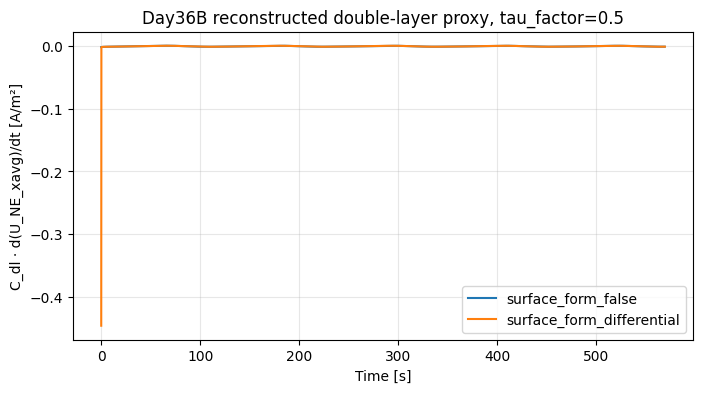

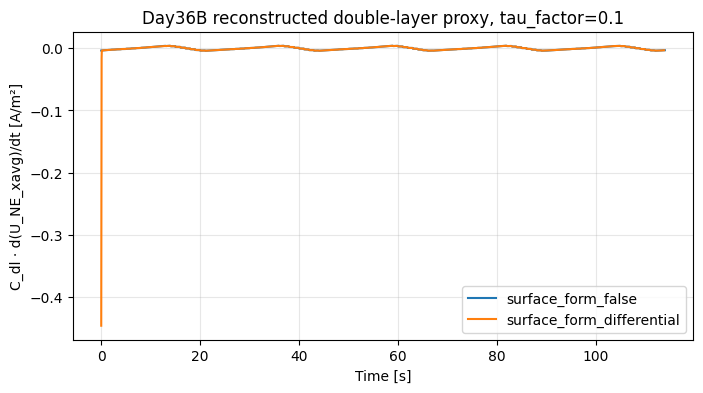

In [18]:
# Cell 18 — Day36B false vs differential summary（Day36B false与differential差异摘要）

# State / margin summary.
state_rows = []

for tau_factor in DAY36B_TAU_FACTORS:
    rows = []
    for variant_id in ["surface_form_false", "surface_form_differential"]:
        cond = day36b_protocol_df[
            (day36b_protocol_df["variant_id"] == variant_id)
            & (day36b_protocol_df["tau_factor_set"] == tau_factor)
        ]["condition"].iloc[0]

        ts = day36b_state_ts_map[cond]
        idx = int(ts["U_NE_min_V"].idxmin())
        r = ts.loc[idx]

        timing = day36b_timing_summary_df[
            (day36b_timing_summary_df["variant_id"] == variant_id)
            & (day36b_timing_summary_df["tau_factor_set"] == tau_factor)
        ].iloc[0]

        rows.append({
            "variant_id": variant_id,
            "tau_factor_set": tau_factor,
            "min_U_NE_mV": float(r["U_NE_min_mV"]),
            "fraction_time_below_0mV": float((ts["U_NE_min_V"] <= 0.0).mean()),
            "Q_end_Ah": float(ts["Q_net_Ah"].max()),
            "Q_at_min_U_NE_Ah": float(r["Q_net_Ah"]),
            "max_c_e_range_molm3": float(ts["c_e_range_molm3"].max()),
            "eta_n_at_min_U_NE_V": float(r["eta_n_V"]),
            "neg_avg_sto_at_min_U_NE": float(r["neg_avg_sto"]),
            "neg_surface_sto_xavg_at_min_U_NE": float(r["neg_surface_sto_xavg"]),
            "j_dl_proxy_neg_abs_max_A_m2": float(np.nanmax(np.abs(ts["j_dl_proxy_neg_A_m2"]))),
            "j_dl_proxy_neg_rms_A_m2": float(np.sqrt(np.nanmean(ts["j_dl_proxy_neg_A_m2"] ** 2))),
            "delta_t_raw_mean_s": float(timing["delta_t_raw_mean_s"]),
            "delta_t_resid_mean_s": float(timing["delta_t_resid_mean_s"]),
            "resid_abs_mean_s": float(timing["resid_abs_mean_s"]),
        })

    false_row = [r for r in rows if r["variant_id"] == "surface_form_false"][0]
    diff_row = [r for r in rows if r["variant_id"] == "surface_form_differential"][0]

    out_row = {"tau_factor_set": tau_factor}

    for key in [
        "min_U_NE_mV",
        "fraction_time_below_0mV",
        "Q_end_Ah",
        "Q_at_min_U_NE_Ah",
        "max_c_e_range_molm3",
        "eta_n_at_min_U_NE_V",
        "neg_avg_sto_at_min_U_NE",
        "neg_surface_sto_xavg_at_min_U_NE",
        "j_dl_proxy_neg_abs_max_A_m2",
        "j_dl_proxy_neg_rms_A_m2",
        "delta_t_raw_mean_s",
        "delta_t_resid_mean_s",
        "resid_abs_mean_s",
    ]:
        out_row[f"{key}_false"] = false_row[key]
        out_row[f"{key}_differential"] = diff_row[key]
        out_row[f"delta_{key}_diff_minus_false"] = diff_row[key] - false_row[key]

    state_rows.append(out_row)

day36b_delta_summary_df = pd.DataFrame(state_rows)

out = DATA_DIR / "day36b_high_frequency_delta_false_vs_differential.csv"
day36b_delta_summary_df.to_csv(out, index=False)

print("[OK] saved Day36B false-vs-differential delta summary:", out)
display(day36b_delta_summary_df)


# Plot reconstructed Cdl proxy.
for tau_factor in DAY36B_TAU_FACTORS:
    fig, ax = plt.subplots(figsize=(8, 4))

    for variant_id in ["surface_form_false", "surface_form_differential"]:
        cond = day36b_protocol_df[
            (day36b_protocol_df["variant_id"] == variant_id)
            & (day36b_protocol_df["tau_factor_set"] == tau_factor)
        ]["condition"].iloc[0]
        ts = day36b_state_ts_map[cond]

        # Show first few cycles for readability.
        mask = ts["t_s"] <= min(ts["t_s"].max(), 5 * (1.0 / (1.0 / (2.0 * np.pi * tau_factor * TAU_REF_SET_S))))
        ax.plot(ts.loc[mask, "t_s"], ts.loc[mask, "j_dl_proxy_neg_A_m2"], label=variant_id)

    ax.set_xlabel("Time [s]")
    ax.set_ylabel("C_dl · d(U_NE_xavg)/dt [A/m²]")
    ax.set_title(f"Day36B reconstructed double-layer proxy, tau_factor={tau_factor}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

In [19]:
# Cell 19 — Day36 final synthesis table（Day36最终综合表）

# 1) Compact model-option evidence
model_option_summary_df = model_variant_audit_df.merge(
    cdl_parameter_audit_df.pivot_table(
        index="parameter_set",
        columns="parameter_key",
        values="available",
        aggfunc="first",
    ).reset_index(),
    left_on=None,
    right_on=None,
    how="cross",
)

# Simpler explicit summary rows.
option_rows = []

for _, row in model_variant_audit_df.iterrows():
    option_rows.append({
        "variant_id": row["variant_id"],
        "surface_form": row["surface_form"],
        "build_status": row["build_status"],
        "n_variables": row["n_variables"],
        "required_margin_keys_available": row["required_margin_keys_available"],
        "negative_Cdl_available": bool(cdl_parameter_audit_df.loc[
            cdl_parameter_audit_df["parameter_key"] == "Negative electrode double-layer capacity [F.m-2]",
            "available"
        ].iloc[0]),
        "positive_Cdl_available": bool(cdl_parameter_audit_df.loc[
            cdl_parameter_audit_df["parameter_key"] == "Positive electrode double-layer capacity [F.m-2]",
            "available"
        ].iloc[0]),
        "negative_Cdl_value": cdl_parameter_audit_df.loc[
            cdl_parameter_audit_df["parameter_key"] == "Negative electrode double-layer capacity [F.m-2]",
            "value_repr"
        ].iloc[0],
        "positive_Cdl_value": cdl_parameter_audit_df.loc[
            cdl_parameter_audit_df["parameter_key"] == "Positive electrode double-layer capacity [F.m-2]",
            "value_repr"
        ].iloc[0],
    })

day36_option_synthesis_df = pd.DataFrame(option_rows)

out = DATA_DIR / "day36_option_synthesis.csv"
day36_option_synthesis_df.to_csv(out, index=False)

print("[OK] saved option synthesis:", out)
display(day36_option_synthesis_df)


# 2) Mainline 1.5τ surface-form verdict table.
mainline_rows = []

for _, row in ledger_df.iterrows():
    mainline_rows.append({
        "section": "Day36A_mainline_1p5tau",
        "variant_id": row["variant_id"],
        "surface_form": row["surface_form"],
        "protocol_id": row["protocol_id"],
        "min_U_NE_mV": row["min_U_NE_mV"],
        "margin_class": row["margin_class"],
        "fraction_time_below_0mV": row["fraction_time_below_0mV"],
        "Q_end_Ah": row["Q_end_Ah"],
        "max_c_e_range_molm3": row["max_c_e_range_molm3"],
        "delta_t_raw_mean_s": row["delta_t_raw_mean_s"],
        "delta_t_geom_mean_s": row["delta_t_geom_mean_s"],
        "delta_t_resid_mean_s": row["delta_t_resid_mean_s"],
        "resid_abs_mean_s": row["resid_abs_mean_s"],
        "dt_resid_class": row["dt_resid_class"],
        "neg_cap_current_abs_max": row["neg_cap_current_abs_max"],
        "pos_cap_current_abs_max": row["pos_cap_current_abs_max"],
    })

day36_mainline_synthesis_df = pd.DataFrame(mainline_rows)

out = DATA_DIR / "day36_mainline_surface_form_synthesis.csv"
day36_mainline_synthesis_df.to_csv(out, index=False)

print("[OK] saved mainline synthesis:", out)
display(day36_mainline_synthesis_df)


# 3) High-frequency false-vs-differential verdict table.
hf_rows = []

for _, row in day36b_delta_summary_df.iterrows():
    tau_factor = row["tau_factor_set"]

    if abs(row["delta_delta_t_resid_mean_s_diff_minus_false"]) < 1.0:
        residual_effect_class = "small_residual_change"
    elif row["delta_delta_t_resid_mean_s_diff_minus_false"] > 0:
        residual_effect_class = "positive_residual_shift"
    else:
        residual_effect_class = "negative_residual_shift"

    if abs(row["delta_min_U_NE_mV_diff_minus_false"]) < 1.0:
        margin_effect_class = "negligible_margin_change"
    elif row["delta_min_U_NE_mV_diff_minus_false"] > 0:
        margin_effect_class = "slightly_higher_margin"
    else:
        margin_effect_class = "slightly_lower_margin"

    hf_rows.append({
        "section": "Day36B_high_frequency",
        "tau_factor_set": tau_factor,
        "min_U_NE_mV_false": row["min_U_NE_mV_false"],
        "min_U_NE_mV_differential": row["min_U_NE_mV_differential"],
        "delta_min_U_NE_mV_diff_minus_false": row["delta_min_U_NE_mV_diff_minus_false"],
        "fraction_time_below_0mV_false": row["fraction_time_below_0mV_false"],
        "fraction_time_below_0mV_differential": row["fraction_time_below_0mV_differential"],
        "delta_t_raw_mean_s_false": row["delta_t_raw_mean_s_false"],
        "delta_t_raw_mean_s_differential": row["delta_t_raw_mean_s_differential"],
        "delta_delta_t_raw_mean_s_diff_minus_false": row["delta_delta_t_raw_mean_s_diff_minus_false"],
        "delta_t_resid_mean_s_false": row["delta_t_resid_mean_s_false"],
        "delta_t_resid_mean_s_differential": row["delta_t_resid_mean_s_differential"],
        "delta_delta_t_resid_mean_s_diff_minus_false": row["delta_delta_t_resid_mean_s_diff_minus_false"],
        "resid_abs_mean_s_false": row["resid_abs_mean_s_false"],
        "resid_abs_mean_s_differential": row["resid_abs_mean_s_differential"],
        "j_dl_proxy_neg_abs_max_A_m2_false": row["j_dl_proxy_neg_abs_max_A_m2_false"],
        "j_dl_proxy_neg_abs_max_A_m2_differential": row["j_dl_proxy_neg_abs_max_A_m2_differential"],
        "j_dl_proxy_neg_rms_A_m2_false": row["j_dl_proxy_neg_rms_A_m2_false"],
        "j_dl_proxy_neg_rms_A_m2_differential": row["j_dl_proxy_neg_rms_A_m2_differential"],
        "residual_effect_class": residual_effect_class,
        "margin_effect_class": margin_effect_class,
    })

day36_high_frequency_synthesis_df = pd.DataFrame(hf_rows)

out = DATA_DIR / "day36_high_frequency_surface_form_synthesis.csv"
day36_high_frequency_synthesis_df.to_csv(out, index=False)

print("[OK] saved high-frequency synthesis:", out)
display(day36_high_frequency_synthesis_df)


# 4) Final compact conclusion table.
final_rows = [
    {
        "claim": "C_dl parameters are available in Chen2020",
        "evidence": "Negative and positive electrode double-layer capacity parameters are present and equal to 0.2 F/m².",
        "verdict": "supported",
        "boundary": "Parameter availability alone does not mean the physics is active unless surface form is enabled.",
    },
    {
        "claim": "surface form = differential builds and runs",
        "evidence": "DFN builds and solves for DC03, fixed AC0.38, fixed AC0.7, and sched_v2.",
        "verdict": "supported",
        "boundary": "Only Chen2020 / DFN / isothermal was tested.",
    },
    {
        "claim": "differential surface form materially changes 1.5τ timing",
        "evidence": "At 1.5τ, Δt_raw and Δt_resid changes versus false are small; all non-DC protocols remain geometry-dominated.",
        "verdict": "not_supported",
        "boundary": "Does not exclude effects at other models, C_dl values, or much higher frequencies.",
    },
    {
        "claim": "differential surface form changes plating-margin classification",
        "evidence": "min U_NE changes are sub-mV scale at 1.5τ and high-frequency tests; margin classes remain unchanged.",
        "verdict": "not_supported",
        "boundary": "U_NE remains a thermodynamic proxy, not direct plating evidence.",
    },
    {
        "claim": "high-frequency forcing makes double-layer proxy visible",
        "evidence": "Reconstructed C_dl·d(U_NE_xavg)/dt proxy is much larger for differential than false at 0.5τ and 0.1τ.",
        "verdict": "supported_as_proxy",
        "boundary": "Proxy is reconstructed from U_NE_xavg and is not a direct PyBaMM capacitive-current output variable.",
    },
    {
        "claim": "missing double-layer differential dynamics explains absent non-geometric acceleration",
        "evidence": "Even with differential surface form, Δt_resid remains near-zero or small; 0.1τ shows a more negative residual shift, not positive acceleration.",
        "verdict": "not_supported_under_tested_conditions",
        "boundary": "Statement applies to tested Chen2020 / DFN / isothermal / 0.1–1.5τ conditions only.",
    },
]

day36_final_conclusion_df = pd.DataFrame(final_rows)

out = DATA_DIR / "day36_final_conclusion_table.csv"
day36_final_conclusion_df.to_csv(out, index=False)

print("[OK] saved final conclusion table:", out)
display(day36_final_conclusion_df)


[OK] saved option synthesis: /Users/louislu/pybamm-dcac-superimposed/data/day36_option_synthesis.csv


,variant_id,surface_form,build_status,n_variables,required_margin_keys_available,negative_Cdl_available,positive_Cdl_available,negative_Cdl_value,positive_Cdl_value
0,surface_form_false,false,ok,515,True,True,True,0.2,0.2
1,surface_form_differential,differential,ok,522,True,True,True,0.2,0.2
2,surface_form_algebraic,algebraic,ok,522,True,True,True,0.2,0.2


[OK] saved mainline synthesis: /Users/louislu/pybamm-dcac-superimposed/data/day36_mainline_surface_form_synthesis.csv


,section,variant_id,surface_form,protocol_id,min_U_NE_mV,margin_class,fraction_time_below_0mV,Q_end_Ah,max_c_e_range_molm3,delta_t_raw_mean_s,delta_t_geom_mean_s,delta_t_resid_mean_s,resid_abs_mean_s,dt_resid_class,neg_cap_current_abs_max,pos_cap_current_abs_max
0,Day36A_mainline_1p5tau,surface_form_false,false,DC03,37.280562,near_boundary,0.000000,4.492879,377.868423,0.000000,0.000000,0.000000,0.000000,dc_reference,NaN,NaN
1,Day36A_mainline_1p5tau,surface_form_false,false,fixed_AC0p38,0.565686,near_boundary,0.000000,3.906509,747.684843,69.350655,69.363536,-0.012881,0.012948,geometry_dominated,NaN,NaN
2,Day36A_mainline_1p5tau,surface_form_false,false,fixed_AC0p7,-25.308203,risk_flag,0.039484,3.633945,1054.089062,158.665349,158.685568,-0.020219,0.020219,geometry_dominated,NaN,NaN
3,Day36A_mainline_1p5tau,surface_form_false,false,sched_v2_conservative,24.160262,near_boundary,0.000000,4.493120,747.684843,65.689082,65.702825,-0.013742,0.013810,geometry_dominated,NaN,NaN
4,Day36A_mainline_1p5tau,surface_form_differential,differential,DC03,37.287613,near_boundary,0.000000,4.492631,378.068256,0.000000,0.000000,0.000000,0.000000,dc_reference,NaN,NaN
5,Day36A_mainline_1p5tau,surface_form_differential,differential,fixed_AC0p38,0.638102,near_boundary,0.000000,3.906268,748.395114,69.391331,69.398991,-0.007660,0.007775,geometry_dominated,NaN,NaN
6,Day36A_mainline_1p5tau,surface_form_differential,differential,fixed_AC0p7,-25.265352,risk_flag,0.040681,3.634027,1054.730226,158.727476,158.743254,-0.015778,0.015778,geometry_dominated,NaN,NaN
7,Day36A_mainline_1p5tau,surface_form_differential,differential,sched_v2_conservative,24.180692,near_boundary,0.000000,4.493142,748.395114,65.723993,65.731800,-0.007807,0.007922,geometry_dominated,NaN,NaN
8,Day36A_mainline_1p5tau,surface_form_algebraic,algebraic,DC03,37.288807,near_boundary,0.000000,4.492531,378.027426,0.000000,0.000000,0.000000,0.000000,dc_reference,NaN,NaN
9,Day36A_mainline_1p5tau,surface_form_algebraic,algebraic,fixed_AC0p38,0.658041,near_boundary,0.000000,3.906076,748.196166,69.349284,69.358475,-0.009191,0.009278,geometry_dominated,NaN,NaN


[OK] saved high-frequency synthesis: /Users/louislu/pybamm-dcac-superimposed/data/day36_high_frequency_surface_form_synthesis.csv


,section,tau_factor_set,min_U_NE_mV_false,min_U_NE_mV_differential,delta_min_U_NE_mV_diff_minus_false,fraction_time_below_0mV_false,fraction_time_below_0mV_differential,delta_t_raw_mean_s_false,delta_t_raw_mean_s_differential,delta_delta_t_raw_mean_s_diff_minus_false,...,delta_t_resid_mean_s_differential,delta_delta_t_resid_mean_s_diff_minus_false,resid_abs_mean_s_false,resid_abs_mean_s_differential,j_dl_proxy_neg_abs_max_A_m2_false,j_dl_proxy_neg_abs_max_A_m2_differential,j_dl_proxy_neg_rms_A_m2_false,j_dl_proxy_neg_rms_A_m2_differential,residual_effect_class,margin_effect_class
0,Day36B_high_frequency,0.5,3.459355,3.498149,0.038794,0.0,0.0,23.185413,23.145363,-0.040050,...,-0.484362,-0.017259,0.467102,0.484362,0.001340,0.44647,0.000353,0.023329,small_residual_change,negligible_margin_change
1,Day36B_high_frequency,0.1,5.802932,5.817346,0.014414,0.0,0.0,4.347608,3.938196,-0.409412,...,-0.716231,-0.473451,0.242780,0.716231,0.004205,0.44647,0.001631,0.015279,small_residual_change,negligible_margin_change


[OK] saved final conclusion table: /Users/louislu/pybamm-dcac-superimposed/data/day36_final_conclusion_table.csv


,claim,evidence,verdict,boundary
0,C_dl parameters are available in Chen2020,Negative and positive electrode double-layer c...,supported,Parameter availability alone does not mean the...
1,surface form = differential builds and runs,"DFN builds and solves for DC03, fixed AC0.38, ...",supported,Only Chen2020 / DFN / isothermal was tested.
2,differential surface form materially changes 1...,"At 1.5τ, Δt_raw and Δt_resid changes versus fa...",not_supported,"Does not exclude effects at other models, C_dl..."
3,differential surface form changes plating-marg...,min U_NE changes are sub-mV scale at 1.5τ and ...,not_supported,"U_NE remains a thermodynamic proxy, not direct..."
4,high-frequency forcing makes double-layer prox...,Reconstructed C_dl·d(U_NE_xavg)/dt proxy is mu...,supported_as_proxy,Proxy is reconstructed from U_NE_xavg and is n...
5,missing double-layer differential dynamics exp...,"Even with differential surface form, Δt_resid ...",not_supported_under_tested_conditions,Statement applies to tested Chen2020 / DFN / i...


## Final closure — Notebook 36

Notebook 36 tested whether the previous DC–AC conclusions were sensitive to the missing double-layer differential surface-form branch.

The audit first confirmed that Chen2020 contains the required double-layer capacity parameters:

- `Negative electrode double-layer capacity [F.m-2] = 0.2`
- `Positive electrode double-layer capacity [F.m-2] = 0.2`

It also confirmed that all surface-form variants build and run:

- `surface form = false`
- `surface form = differential`
- `surface form = algebraic`

The required negative-electrode plating-margin proxy remains available in all variants:

- `Negative electrode surface potential difference [V]`

Day36A compared `false`, `differential`, and `algebraic` at the mainline `1.5τ_set` frequency for:

- DC `0.3C`,
- fixed `0.3C + 0.38C`,
- fixed `0.3C + 0.7C`,
- scheduled `sched_v2_conservative`.

At `1.5τ_set`, enabling `surface form = differential` did not materially change the main conclusions:

- timing remained geometry-dominated;
- `Δt_resid` stayed near zero;
- min U_NE changed only at sub-mV scale;
- margin classes did not change;
- equal-terminal-Q state-progression differences remained very small.

Day36B then tested faster forcing for fixed `0.3C + 0.38C`:

- `0.5τ_set`
- `0.1τ_set`

The reconstructed double-layer proxy,

```text
C_dl · d(U_NE_xavg)/dt
```

was visibly larger for the differential branch than for the false branch. This confirms that enabling `surface form = differential` produces a detectable capacitive dynamic response proxy.

However, this did not translate into engineering-significant non-geometric acceleration:

- at `0.5τ_set`, false and differential both remained geometry-dominated;
- at `0.1τ_set`, the differential branch showed a larger small residual shift, but the residual moved negative rather than positive;
- min U_NE and hard-margin classification remained essentially unchanged;
- terminal-Q and state-progression differences remained small.

Correct conclusion wording:

> In Chen2020 / DFN under the tested 0.1–1.5τ_set DC–AC forcing range, enabling `surface form = differential` introduces visible double-layer proxy dynamics but does not materially change timing, geometry–residual classification, plating-margin verdicts, or equal-terminal-Q state progression. The previous absence of non-geometric acceleration is therefore not explained by omission of differential double-layer surface dynamics under these tested conditions.

Interpretation boundary:

- This conclusion applies only to Chen2020 / DFN / isothermal settings.
- The tested double-layer capacity values are the Chen2020 defaults.
- The reconstructed `C_dl · d(U_NE_xavg)/dt` term is a diagnostic proxy, not a direct PyBaMM capacitive-current output variable.
- This notebook does not exclude double-layer effects under much higher frequencies, altered C_dl sensitivity, other parameter sets, thermal coupling, aging states, or experimental measurement-chain dynamics.
- It does not implement MPC / BO or thermal / aging admissibility.

Next step:

Before moving into more optimization, the project should discuss whether the non-geometric acceleration target is physically absent under the current model class, or whether it is not identifiable under the current terminal-Q / geometry-residual decomposition. This is a claim-level interpretation problem and should be handled separately from additional parameter scanning.
